# Avance 1 y 3 · EDA de los clientes de Chicago
### Proyecto Integrador M1 · *Conociendo al cliente 360°*
**Autor:** Tomás Babot · **Empresa (caso):** InsightReach · **Rol:** Científico de Datos Junior

---

## Contexto
InsightReach crea campañas personalizadas para negocios locales y necesita segmentar mejor a sus clientes. Recibimos una base de 30.000 clientes de restaurantes de 10 ciudades de EE. UU.

| Parte | Secciones |
|---|---|
| **Avance #1:** carga, filtro por ciudad, limpieza y tablas | 1 a 5 |
| **Análisis exploratorio:** estadística descriptiva y gráficos | 6 y 7 |
| **Avance #3:** análisis, interpretación y recomendaciones | 8 a 10 |

## Cómo ejecutarlo
Se ejecuta de arriba hacia abajo. El Avance #1 usa solo la base de clientes y guarda la base limpia en `data/clientes_chicago_limpios.csv`, que usa el Avance #2. El Avance #3 parte de la base unificada que arma `Avance_API_Yelp.ipynb`, que ya está guardada en `data/`. Las rutas son relativas a la carpeta `Avances/`.

## 1. Preparar el entorno

Importamos las librerías (`pandas` y `numpy` para los datos, `matplotlib` y `seaborn` para los gráficos y `scipy` para las pruebas estadísticas) y definimos en un solo lugar los valores que se usan en todo el notebook: rutas, orden de los estratos, rangos de precio y nombres legibles para los gráficos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['text.parse_math'] = False   # para que el símbolo $ no se lea como una fórmula
pd.set_option('display.max_columns', None)

RUTA_DATA = Path('../data')
ORDEN_ESTRATO = ['Bajo', 'Medio', 'Alto', 'Muy Alto']   # el estrato tiene un orden lógico
RANGOS_PRECIO = [0, 10, 30, 60, 1000]                   # cortes en USD de los rangos de precio de Yelp
ETIQUETAS_PRECIO = ['$', '$$', '$$$', '$$$$']

# Nombres legibles para los títulos y ejes de los gráficos
NOMBRES = {
    'edad': 'Edad (años)', 'frecuencia_visita': 'Frecuencia de visita', 'promedio_gasto_comida': 'Gasto por visita (USD)',
    'ingresos_mensuales': 'Ingreso mensual (USD)', 'genero': 'Género', 'preferencias_alimenticias': 'Preferencia alimenticia',
    'consume_licor': 'Consume licor', 'estrato_socioeconomico': 'Estrato', 'ocio': 'Ocio', 'membresia_premium': 'Membresía premium',
    'tipo_de_pago_mas_usado': 'Medio de pago', 'grupo_edad': 'Grupo de edad',
}

### Funciones auxiliares
Algunas operaciones se repiten muchas veces en el análisis. En lugar de copiar el mismo código, las escribimos una sola vez como funciones:
- `tabla_frecuencias`: cuántos clientes hay en cada categoría y qué porcentaje representan.
- `tabla_porcentajes`: tabla cruzada con el porcentaje dentro de cada fila (por ejemplo, % que consume licor en cada estrato).
- `p_valor_kruskal`: prueba de Kruskal-Wallis para saber si un valor numérico (como el gasto) cambia entre grupos.

In [2]:
def tabla_frecuencias(serie):
    """Cuántos clientes hay en cada categoría y qué porcentaje representan."""
    return pd.DataFrame({
        'conteo': serie.value_counts(),
        'porcentaje': (serie.value_counts(normalize=True) * 100).round(2),
    })


def tabla_porcentajes(filas, columnas, orden=None):
    """Tabla cruzada con el % de cada categoría de `columnas` dentro de cada fila."""
    tabla = pd.crosstab(filas, columnas, normalize='index').mul(100).round(1)
    if orden is not None:
        tabla = tabla.reindex(orden)   # para respetar un orden lógico, como el del estrato
    return tabla


def p_valor_kruskal(df, grupo, valor):
    """Prueba de Kruskal-Wallis: ¿`valor` cambia según el `grupo`? Devuelve el p-valor."""
    datos_por_grupo = [datos for nombre, datos in df.groupby(grupo, observed=True)[valor]]
    return stats.kruskal(*datos_por_grupo).pvalue

## 2. Cargar y explorar la base de clientes

Leemos el CSV y revisamos tamaño, tipos de dato y una muestra de filas antes de limpiar.

In [3]:
df_raw = pd.read_csv(RUTA_DATA / 'base_datos_restaurantes_USA_v2.csv')
print(f'Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}')
df_raw.head()

Filas: 30,000 | Columnas: 17


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  object 
 2   apellido                   30000 non-null  object 
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  object 
 5   ciudad_residencia          30000 non-null  object 
 6   estrato_socioeconomico     30000 non-null  object 
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  object 
 10  consume_licor              30000 non-null  object 
 11  preferencias_alimenticias  28597 non-null  object 
 12  membresia_premium          30000 non-null  object 
 13  telefono_contacto          14834 non-null  obj

In [5]:
# Resumen estadístico automático de las columnas numéricas
df_raw.describe().round(2)

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.00,30000.00,29855.00,30000.00
mean,5.504765e+09,49.67,3.90,32.60,5389.76
std,2.602799e+09,23.84,2.74,26.40,4538.49
min,1.000153e+09,-5.00,-3.00,0.00,800.00
25%,3.243617e+09,33.00,2.00,13.29,1860.00
50%,5.515865e+09,49.00,4.00,25.51,3402.00
75%,7.754426e+09,65.00,5.00,44.40,7761.00
max,9.999627e+09,300.00,10.00,149.97,17999.00


**Diccionario de variables**

| Variable | Tipo | Significado |
|---|---|---|
| `id_persona` | identificador | Código único del cliente |
| `nombre`, `apellido`, `telefono_contacto`, `correo_electronico` | datos personales | Sirven para contactar, no para analizar |
| `edad` | numérica | Edad en años |
| `genero` | categórica | Femenino / Masculino |
| `ciudad_residencia` | categórica | Una de las 10 ciudades de la base |
| `estrato_socioeconomico` | categórica **ordinal** | Bajo < Medio < Alto < Muy Alto |
| `frecuencia_visita` | numérica | Cantidad de visitas a restaurantes (escala de 0 a 10) |
| `promedio_gasto_comida` | numérica | Gasto promedio por visita (USD) |
| `ocio`, `consume_licor`, `membresia_premium` | categóricas (Sí/No) | Hábitos y suscripción |
| `preferencias_alimenticias` | categórica | Carnes, Mariscos, Pescado, Vegetariano, Vegano u Otro |
| `tipo_de_pago_mas_usado` | categórica | Efectivo, Tarjeta, App o Criptomoneda |
| `ingresos_mensuales` | numérica | Ingreso mensual (USD) |

Ya se ven problemas de calidad: una `edad` mínima de -5 y máxima de 300, y `frecuencia_visita` negativa. Los tratamos en la sección 4.

## 3. Filtrar la base por una ciudad específica

Las campañas son locales y cada ciudad tiene su propia oferta, así que analizamos una ciudad a la vez. Además, en el Avance #2 cruzamos los clientes con los restaurantes de Yelp de esa ciudad.

### 3.1 ¿Cuántos clientes hay por ciudad?
Agrupamos por ciudad con `groupby` y contamos los `id_persona` (cada persona tiene un id único). Con `reset_index` y `rename` lo dejamos como tabla:

In [6]:
df_clientes_por_ciudad = df_raw.groupby('ciudad_residencia')['id_persona'].count().reset_index()
df_clientes_por_ciudad = df_clientes_por_ciudad.rename(columns={'id_persona': 'cantidad_clientes'})
df_clientes_por_ciudad

,ciudad_residencia,cantidad_clientes
0,Boston,2547
1,Chicago,5384
2,Dallas,2602
3,Denver,2523
4,Houston,2212
5,Miami,3186
6,NYC,4769
7,Phoenix,1511
8,San Diego,3075
9,Seattle,2191


### 3.2 Porcentaje de cada ciudad y gráfico

In [7]:
total_clientes = df_clientes_por_ciudad['cantidad_clientes'].sum()
df_clientes_por_ciudad['porcentaje'] = (df_clientes_por_ciudad['cantidad_clientes'] / total_clientes * 100).round(2)

# Ordenamos de la ciudad con más clientes a la que tiene menos
df_clientes_por_ciudad = df_clientes_por_ciudad.sort_values('cantidad_clientes', ascending=False)
df_clientes_por_ciudad

,ciudad_residencia,cantidad_clientes,porcentaje
1,Chicago,5384,17.95
6,NYC,4769,15.90
5,Miami,3186,10.62
8,San Diego,3075,10.25
2,Dallas,2602,8.67
0,Boston,2547,8.49
3,Denver,2523,8.41
4,Houston,2212,7.37
9,Seattle,2191,7.30
7,Phoenix,1511,5.04


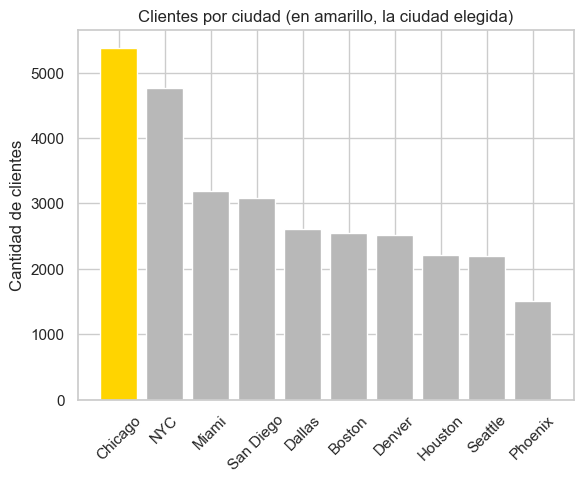

In [8]:
CIUDAD = 'Chicago'
colores = ['#ffd400' if ciudad == CIUDAD else '#b8b8b8' for ciudad in df_clientes_por_ciudad['ciudad_residencia']]

plt.bar(df_clientes_por_ciudad['ciudad_residencia'], df_clientes_por_ciudad['cantidad_clientes'], color=colores)
plt.title('Clientes por ciudad (en amarillo, la ciudad elegida)')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)
plt.show()

### 3.3 Filtrar la ciudad elegida

In [9]:
df_ciudad = df_raw[df_raw['ciudad_residencia'] == CIUDAD].copy()
print(f'Clientes de {CIUDAD}: {len(df_ciudad):,} ({len(df_ciudad) / len(df_raw):.1%} de la base)')

Clientes de Chicago: 5,384 (17.9% de la base)


**Criterio de elección: Chicago.**
1. Es la ciudad con más clientes (5.384, cerca del 18%), lo que da muestras más grandes en cada segmento.
2. Tiene mucha oferta en Yelp, lo que enriquece el cruce del Avance #2.

Desde acá trabajamos sobre `df_ciudad` y dejamos `df_raw` intacto.

## 4. Limpieza de datos

Primero detectamos los problemas (4.1 a 4.3), después los tratamos (4.4), verificamos el resultado (4.5) y guardamos la base limpia (4.6).

### 4.1 Valores nulos

In [10]:
nulos = pd.DataFrame({
    'nulos': df_ciudad.isnull().sum(),
    'porcentaje': (df_ciudad.isnull().mean() * 100).round(2),
})
nulos[nulos['nulos'] > 0].sort_values('nulos', ascending=False)

,nulos,porcentaje
telefono_contacto,2730,50.71
correo_electronico,2712,50.37
preferencias_alimenticias,268,4.98
promedio_gasto_comida,35,0.65
edad,23,0.43


In [11]:
# Correo y teléfono tienen ~50% de nulos cada uno: ¿cuántos clientes no tienen ninguno de los dos?
sin_contacto = df_ciudad['correo_electronico'].isnull() & df_ciudad['telefono_contacto'].isnull()
print(f'Clientes sin correo ni teléfono: {sin_contacto.sum():,} ({sin_contacto.mean():.1%})')

Clientes sin correo ni teléfono: 1,359 (25.2%)


**Interpretación:**
- `telefono_contacto` y `correo_electronico` tienen ~50% de nulos y no aportan al análisis: los descartamos.
- Correo y teléfono se complementan: 1.359 clientes (25%) no tienen ninguno de los dos, así que no se los puede contactar directamente. Lo tenemos en cuenta en las recomendaciones (sección 9).
- `preferencias_alimenticias` tiene 268 nulos (5%).
- `promedio_gasto_comida` (35 casos) y `edad` (23 casos) tienen muy pocos nulos y se pueden imputar.

### 4.2 Duplicados

In [12]:
print('Filas duplicadas exactas:              ', df_ciudad.duplicated().sum())
print('id_persona repetidos:                  ', df_ciudad['id_persona'].duplicated().sum())
print('Filas idénticas ignorando id_persona:  ', df_ciudad.drop(columns='id_persona').duplicated().sum())
print('Correos repetidos (sin contar nulos):  ', df_ciudad['correo_electronico'].dropna().duplicated().sum())

Filas duplicadas exactas:               0
id_persona repetidos:                   0
Filas idénticas ignorando id_persona:   0
Correos repetidos (sin contar nulos):   14


In [13]:
# Posibles homónimos: mismo nombre, apellido y edad
repetidos = df_ciudad.duplicated(subset=['nombre', 'apellido', 'edad'], keep=False)
df_ciudad[repetidos].sort_values(['apellido', 'nombre'])[['id_persona', 'nombre', 'apellido', 'edad', 'genero',
                                                          'estrato_socioeconomico', 'ingresos_mensuales']]

,id_persona,nombre,apellido,edad,genero,estrato_socioeconomico,ingresos_mensuales
5893,9411532909,William,Gibson,34.0,Masculino,Bajo,1027
11496,3925995469,William,Gibson,34.0,Masculino,Alto,6567
151,9954587710,Matthew,Martinez,63.0,Masculino,Alto,6006
14565,5449634185,Matthew,Martinez,63.0,Masculino,Medio,2070
6477,8581299821,Robert,Smith,58.0,Masculino,Alto,5526
19544,3190453309,Robert,Smith,58.0,Masculino,Medio,2511


**Interpretación:**
- No hay duplicados que eliminar: no hay filas repetidas ni `id_persona` repetidos.
- Los 3 pares de homónimos (mismo nombre, apellido, edad y género) tienen distinto id, estrato e ingresos: son personas diferentes.
- Hay 14 correos repetidos entre clientes distintos. No se usan en el análisis, pero es un problema de calidad del origen.

### 4.3 Errores y valores imposibles

In [14]:
columnas_numericas = ['edad', 'frecuencia_visita', 'promedio_gasto_comida', 'ingresos_mensuales']

print('Edades menores a 18 o mayores a 100:  ', ((df_ciudad['edad'] < 18) | (df_ciudad['edad'] > 100)).sum())
print('Frecuencias de visita negativas:      ', (df_ciudad['frecuencia_visita'] < 0).sum())
print('Gastos negativos:                     ', (df_ciudad['promedio_gasto_comida'] < 0).sum())
print('Ingresos menores o iguales a 0:       ', (df_ciudad['ingresos_mensuales'] <= 0).sum())

Edades menores a 18 o mayores a 100:   29
Frecuencias de visita negativas:       286
Gastos negativos:                      0
Ingresos menores o iguales a 0:        0


In [15]:
# ¿Qué valores tienen esas edades imposibles?
edades_raras = df_ciudad[(df_ciudad['edad'] < 18) | (df_ciudad['edad'] > 100)]
edades_raras['edad'].value_counts()

edad
-5.0      16
 300.0    13
Name: count, dtype: int64

In [16]:
# Distribución de frecuencia_visita (¿hay valores raros?)
df_ciudad['frecuencia_visita'].value_counts().sort_index()

frecuencia_visita
-3      286
 0      261
 1      273
 2      649
 3      715
 4      921
 5     1059
 6      642
 7      164
 8      124
 9      141
 10     149
Name: count, dtype: int64

In [17]:
# ¿El gasto 0 es un error? Lo comparamos con la frecuencia de visita 0.
pd.crosstab(df_ciudad['frecuencia_visita'] == 0, df_ciudad['promedio_gasto_comida'] == 0,
            rownames=['frecuencia_visita == 0'], colnames=['gasto == 0'])

gasto == 0,False,True
frecuencia_visita == 0,,
False,5123,0
True,0,261


**Interpretación:**
- `edad`: 29 clientes con valores imposibles (-5 y 300), errores de carga.
- `frecuencia_visita`: 286 clientes con -3, un valor que no puede existir.
- Gasto igual a 0 no es un error: los 261 clientes con gasto 0 son exactamente los 261 con `frecuencia_visita == 0`. No visitan, así que lo conservamos.
- Ingresos y gasto no tienen negativos. Los valores altos son clientes reales de alto poder adquisitivo y no se eliminan (ver los boxplots de 7.3).

### 4.4 Tratamiento

| Problema | Decisión | Justificación |
|---|---|---|
| `edad` fuera de 18-100 o nula | Pasa a `NaN` y se rellena con la **mediana general** | Son errores de carga (-5 y 300). La mediana es robusta a valores extremos, y la edad no depende del estrato. |
| `frecuencia_visita` negativa | Pasa a `NaN` y se rellena con la **mediana de su estrato** | Una frecuencia negativa es imposible. Y la frecuencia cambia mucho según el estrato (ver la tabla de abajo), así que la mediana general le inventaría visitas a los clientes de estrato Bajo y se las quitaría a los de Muy Alto. |
| `promedio_gasto_comida` nulo | Se rellena con la **mediana de su estrato** | Pocos casos y distribución asimétrica: la mediana representa mejor al cliente típico, y el gasto también depende del estrato. |
| `preferencias_alimenticias` nula | Categoría explícita **`'Sin dato'`** | No inventamos una preferencia y evitamos que los gráficos oculten estos clientes sin avisar. |
| Gasto igual a 0 | **Se conserva** | Coincide exactamente con `frecuencia_visita == 0`: son clientes que no visitan, no un error. |
| `nombre`, `apellido`, `telefono_contacto`, `correo_electronico` | Se **eliminan** de la base de trabajo | No aportan al análisis (teléfono y correo tienen ~50% de nulos) y protegen datos personales al publicar el repositorio. |
| Duplicados | No hay que eliminar nada | Ver 4.2. |

**¿Por qué la mediana de cada estrato?** Antes de imputar miramos la frecuencia y el gasto típicos de cada estrato, usando solo los valores válidos:

In [18]:
# Frecuencia y gasto típicos (mediana) de cada estrato, sin contar los errores ni los nulos
validos = df_ciudad[df_ciudad['frecuencia_visita'] >= 0]
validos.groupby('estrato_socioeconomico')[['frecuencia_visita', 'promedio_gasto_comida']].median().reindex(ORDEN_ESTRATO)

,frecuencia_visita,promedio_gasto_comida
estrato_socioeconomico,,
Bajo,2.0,6.765
Medio,4.0,17.580
Alto,5.0,32.915
Muy Alto,7.0,53.110


**Interpretación:** la frecuencia típica va de 2 visitas en el estrato Bajo a 7 en el Muy Alto, y el gasto también sube mucho con el estrato. Si a todos les pusiéramos la mediana general (4 visitas), los 286 clientes con frecuencia -3 quedarían con una frecuencia que no corresponde a su nivel. Por eso cada cliente recibe la mediana de su propio estrato.

Juntamos todos los pasos de la limpieza en una función, `limpiar_clientes`. Así el proceso queda en un solo lugar y se puede repetir con otra ciudad. La función trabaja sobre una copia, así que `df_ciudad` queda intacto:

In [19]:
def limpiar_clientes(df):
    """Aplica la limpieza de la sección 4 y devuelve una base nueva, sin modificar la original."""
    df = df.copy()

    # Paso 1: los errores pasan a ser nulos (NaN)
    df.loc[(df['edad'] < 18) | (df['edad'] > 100), 'edad'] = np.nan
    df.loc[df['frecuencia_visita'] < 0, 'frecuencia_visita'] = np.nan

    # Paso 2: la edad faltante se rellena con la mediana general (la edad no depende del estrato)
    df['edad'] = df['edad'].fillna(df['edad'].median())

    # Paso 3: frecuencia y gasto faltantes se rellenan con la mediana del estrato de cada cliente
    for col in ['frecuencia_visita', 'promedio_gasto_comida']:
        mediana_del_estrato = df.groupby('estrato_socioeconomico')[col].transform('median')
        df[col] = df[col].fillna(mediana_del_estrato)

    # Paso 4: la preferencia faltante pasa a ser una categoría explícita
    df['preferencias_alimenticias'] = df['preferencias_alimenticias'].fillna('Sin dato')

    # Paso 5: sacamos los datos personales
    df = df.drop(columns=['nombre', 'apellido', 'telefono_contacto', 'correo_electronico'])

    # Paso 6: edad y frecuencia son enteros (habían quedado con decimales por los nulos)
    df['edad'] = df['edad'].astype(int)
    df['frecuencia_visita'] = df['frecuencia_visita'].astype(int)
    return df


df_limpio = limpiar_clientes(df_ciudad)

### 4.5 Verificación del resultado

In [20]:
print('Nulos restantes:', df_limpio.isnull().sum().sum())
print('Filas:', len(df_limpio), '| Columnas:', df_limpio.shape[1])

Nulos restantes: 0
Filas: 5384 | Columnas: 13


In [21]:
# Comparamos antes y después de la limpieza
antes_despues = pd.DataFrame({
    'antes_min': df_ciudad[columnas_numericas].min(), 'despues_min': df_limpio[columnas_numericas].min(),
    'antes_max': df_ciudad[columnas_numericas].max(), 'despues_max': df_limpio[columnas_numericas].max(),
    'antes_media': df_ciudad[columnas_numericas].mean().round(2), 'despues_media': df_limpio[columnas_numericas].mean().round(2),
})
antes_despues

,antes_min,despues_min,antes_max,despues_max,antes_media,despues_media
edad,-5.0,18.0,300.00,80.00,49.18,48.73
frecuencia_visita,-3.0,0.0,10.00,10.00,3.82,4.21
promedio_gasto_comida,0.0,0.0,104.92,104.92,25.53,25.53
ingresos_mensuales,801.0,801.0,17999.00,17999.00,5202.31,5202.31


In [22]:
# Tipos de dato antes y después
tipos_de_dato = pd.DataFrame({'antes': df_ciudad.dtypes.astype(str), 'despues': df_limpio.dtypes.astype(str)})
tipos_de_dato.loc[df_limpio.columns].T

,id_persona,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,tipo_de_pago_mas_usado,ingresos_mensuales
antes,int64,float64,object,object,object,int64,float64,object,object,object,object,object,int64
despues,int64,int64,object,object,object,int64,float64,object,object,object,object,object,int64


**Interpretación:**
- La base queda sin nulos, con 5.384 clientes y 13 columnas (se eliminaron las 4 de datos personales).
- Los rangos son válidos: `edad` entre 18 y 80 y `frecuencia_visita` entre 0 y 10.
- `edad` pasa de `float64` a `int64`; el resto de los tipos no necesita conversión.
- Las medias casi no cambian (edad de 49,18 a 48,73; el gasto queda en 25,53). La de `frecuencia_visita` sube de 3,82 a 4,21 porque desaparecen los -3.

### 4.6 Guardar la base limpia
Guardamos los clientes limpios de Chicago en `data/clientes_chicago_limpios.csv`. Es la entrada del Avance #2 (`Avance_API_Yelp.ipynb`), que la cruza con Yelp. Así la limpieza se hace una sola vez, acá, y los dos notebooks usan exactamente la misma base.

In [23]:
df_limpio.to_csv(RUTA_DATA / 'clientes_chicago_limpios.csv', index=False)
print('Guardado: data/clientes_chicago_limpios.csv')

Guardado: data/clientes_chicago_limpios.csv


## 5. Tabulación: distribución de las variables

Tablas de frecuencia (cantidad y porcentaje) de las variables categóricas, y algunos cruces de a pares.

In [24]:
columnas_categoricas = ['genero', 'preferencias_alimenticias', 'consume_licor', 'estrato_socioeconomico',
                        'ocio', 'membresia_premium', 'tipo_de_pago_mas_usado']

for col in columnas_categoricas:
    print(f'--- {col} ---')
    display(tabla_frecuencias(df_limpio[col]))

--- genero ---


,conteo,porcentaje
genero,,
Masculino,2716,50.45
Femenino,2668,49.55


--- preferencias_alimenticias ---


,conteo,porcentaje
preferencias_alimenticias,,
Carnes,1589,29.51
Vegetariano,1123,20.86
Mariscos,696,12.93
Otro,591,10.98
Vegano,571,10.61
Pescado,546,10.14
Sin dato,268,4.98


--- consume_licor ---


...

,conteo,porcentaje
ocio,,
No,2712,50.37
Sí,2672,49.63


--- membresia_premium ---


,conteo,porcentaje
membresia_premium,,
No,3169,58.86
Sí,2215,41.14


--- tipo_de_pago_mas_usado ---


,conteo,porcentaje
tipo_de_pago_mas_usado,,
Efectivo,2120,39.38
Tarjeta,1790,33.25
App,1375,25.54
Criptomoneda,99,1.84


**Interpretación:**
- **Preferencias:** Carnes es la más frecuente (29,5%), pero Vegetariano (20,9%) y Vegano (10,6%) suman 31,5%, el grupo más grande. Mariscos y pescado juntos suman 23%.
- **Perfil:** género equilibrado (50/50), 62,7% consume licor y 41% tiene membresía premium.
- **Pagos:** efectivo 39%, tarjeta 33%, app 26% y criptomoneda 1,8%.
- **Estratos:** el Medio es el más grande (33%) y el Muy Alto el más chico (17%).

### Tablas cruzadas (porcentaje dentro de cada fila)

In [25]:
# Consumo de licor según estrato socioeconómico (%)
tabla_porcentajes(df_limpio['estrato_socioeconomico'], df_limpio['consume_licor'], ORDEN_ESTRATO)

consume_licor,No,Sí
estrato_socioeconomico,,
Bajo,38.3,61.7
Medio,36.6,63.4
Alto,36.8,63.2
Muy Alto,38.3,61.7


In [26]:
# Preferencia alimenticia según género (%)
tabla_porcentajes(df_limpio['genero'], df_limpio['preferencias_alimenticias'])

preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Sin dato,Vegano,Vegetariano
genero,,,,,,,
Femenino,29.9,12.6,10.5,9.8,5.3,10.7,21.2
Masculino,29.2,13.3,11.5,10.5,4.6,10.5,20.5


In [27]:
# Membresía premium según estrato socioeconómico (%)
tabla_porcentajes(df_limpio['estrato_socioeconomico'], df_limpio['membresia_premium'], ORDEN_ESTRATO)

membresia_premium,No,Sí
estrato_socioeconomico,,
Bajo,99.3,0.7
Medio,86.9,13.1
Alto,27.9,72.1
Muy Alto,4.7,95.3


**Interpretación:**
- El consumo de licor no depende del estrato: ronda 62-63% en los cuatro (el chi-cuadrado de la sección 8 lo confirma).
- La preferencia alimenticia es casi igual entre géneros (diferencias de 1 punto o menos).
- La membresía premium sí depende del estrato: va de 0,7% en Bajo a 95,3% en Muy Alto. Es casi un reflejo del nivel socioeconómico (ver P1).

## 6. Estadística descriptiva

Resumimos las variables numéricas con tendencia central, dispersión y forma (asimetría y curtosis). Si la media y la mediana difieren mucho, hay asimetría o valores extremos.

In [28]:
# .agg() calcula varias medidas de una vez; .T da vuelta la tabla para leerla mejor
resumen = df_limpio[columnas_numericas].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurt']).T
resumen.columns = ['media', 'mediana', 'desvio_std', 'minimo', 'maximo', 'asimetria', 'curtosis']

resumen['moda'] = df_limpio[columnas_numericas].mode().iloc[0]
resumen['iqr'] = df_limpio[columnas_numericas].quantile(0.75) - df_limpio[columnas_numericas].quantile(0.25)
resumen['coef_variacion_%'] = resumen['desvio_std'] / resumen['media'] * 100

resumen.round(2)

,media,mediana,desvio_std,minimo,maximo,asimetria,curtosis,moda,iqr,coef_variacion_%
edad,48.73,49.00,18.05,18.0,80.00,0.02,-1.19,49.0,31.00,37.04
frecuencia_visita,4.21,4.00,2.22,0.0,10.00,0.38,0.20,5.0,2.00,52.62
promedio_gasto_comida,25.53,19.06,22.03,0.0,104.92,1.39,1.61,0.0,25.95,86.28
ingresos_mensuales,5202.31,3244.50,4514.16,801.0,17999.00,1.25,0.53,1267.0,5620.75,86.77


**Interpretación:**
- `edad`: media 48,7 y mediana 49, asimetría ≈ 0 y curtosis de -1,19. La distribución es plana, con clientes repartidos de forma pareja entre 18 y 80.
- `frecuencia_visita`: simétrica, media 4,2 y mediana 4. La mayoría visita entre 3 y 5 veces.
- `promedio_gasto_comida`: asimétrica a la derecha (1,39). La media ($25,53) supera a la mediana ($19,06) porque pocos clientes gastan mucho. Coeficiente de variación de 86%. La moda es 0 por los 261 clientes que no visitan.
- `ingresos_mensuales`: también asimétrica (1,25), con media de $5.202, mediana de $3.244 y coeficiente de variación de 87%.
- Con gasto e ingresos asimétricos, para describir al cliente típico conviene la mediana.

## 7. Análisis exploratorio con visualizaciones

### 7.1 Histogramas de las variables numéricas
La línea roja es la media y la verde la mediana: si están lejos, la distribución es asimétrica.

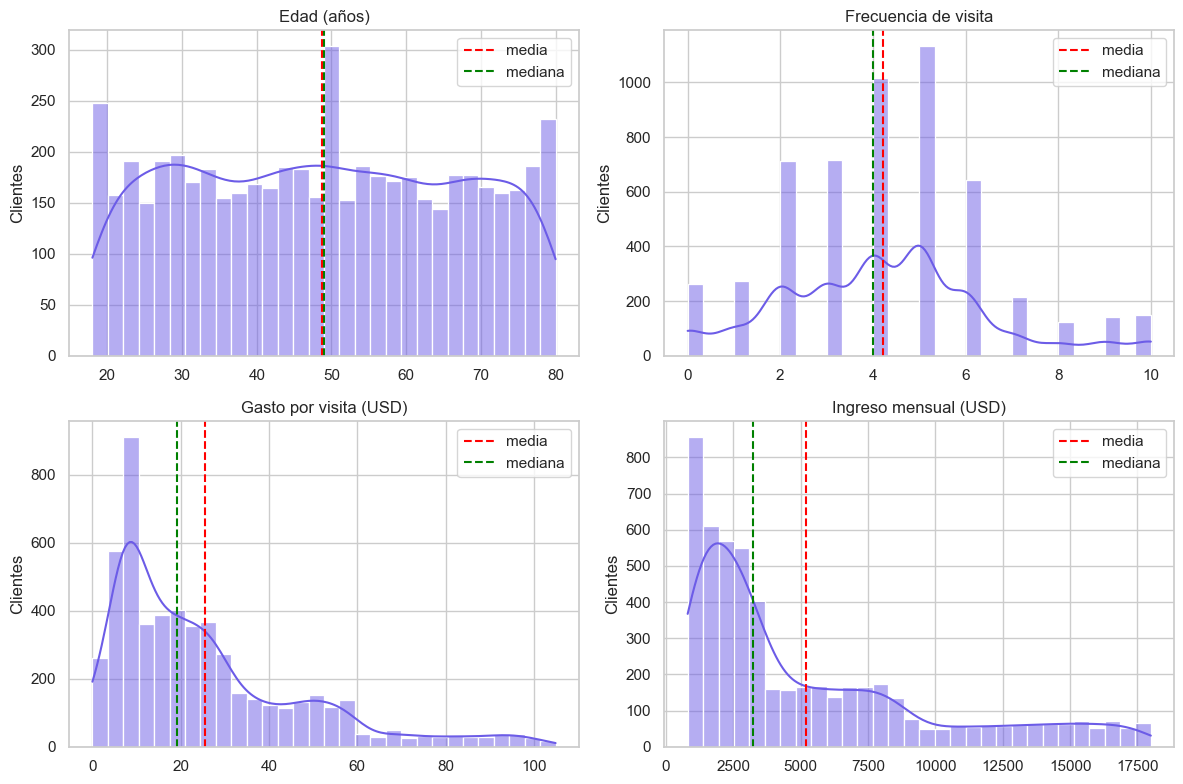

In [29]:
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))   # una grilla de 2 filas x 2 columnas
ejes = ejes.flatten()                             # la convertimos en una lista simple de 4 gráficos

for i, col in enumerate(columnas_numericas):
    sns.histplot(df_limpio[col], bins=30, kde=True, ax=ejes[i], color='#6c5ce7')
    ejes[i].axvline(df_limpio[col].mean(), color='red', linestyle='--', label='media')
    ejes[i].axvline(df_limpio[col].median(), color='green', linestyle='--', label='mediana')
    ejes[i].set_title(NOMBRES[col])
    ejes[i].set_xlabel('')
    ejes[i].set_ylabel('Clientes')
    ejes[i].legend()

plt.tight_layout()
plt.show()

**Interpretación:**
- `edad` es casi uniforme entre 18 y 80, sin grupo dominante.
- `frecuencia_visita` forma una campana centrada en 4-5 visitas, con un grupo chico que visita 10 veces.
- Gasto e ingresos tienen cola larga a la derecha (la media queda a la derecha de la mediana). Hay un pico de gasto en 0, los clientes que no visitan.

### 7.2 Variables categóricas (countplots)
Barras ordenadas de mayor a menor, salvo el estrato, que tiene un orden propio.

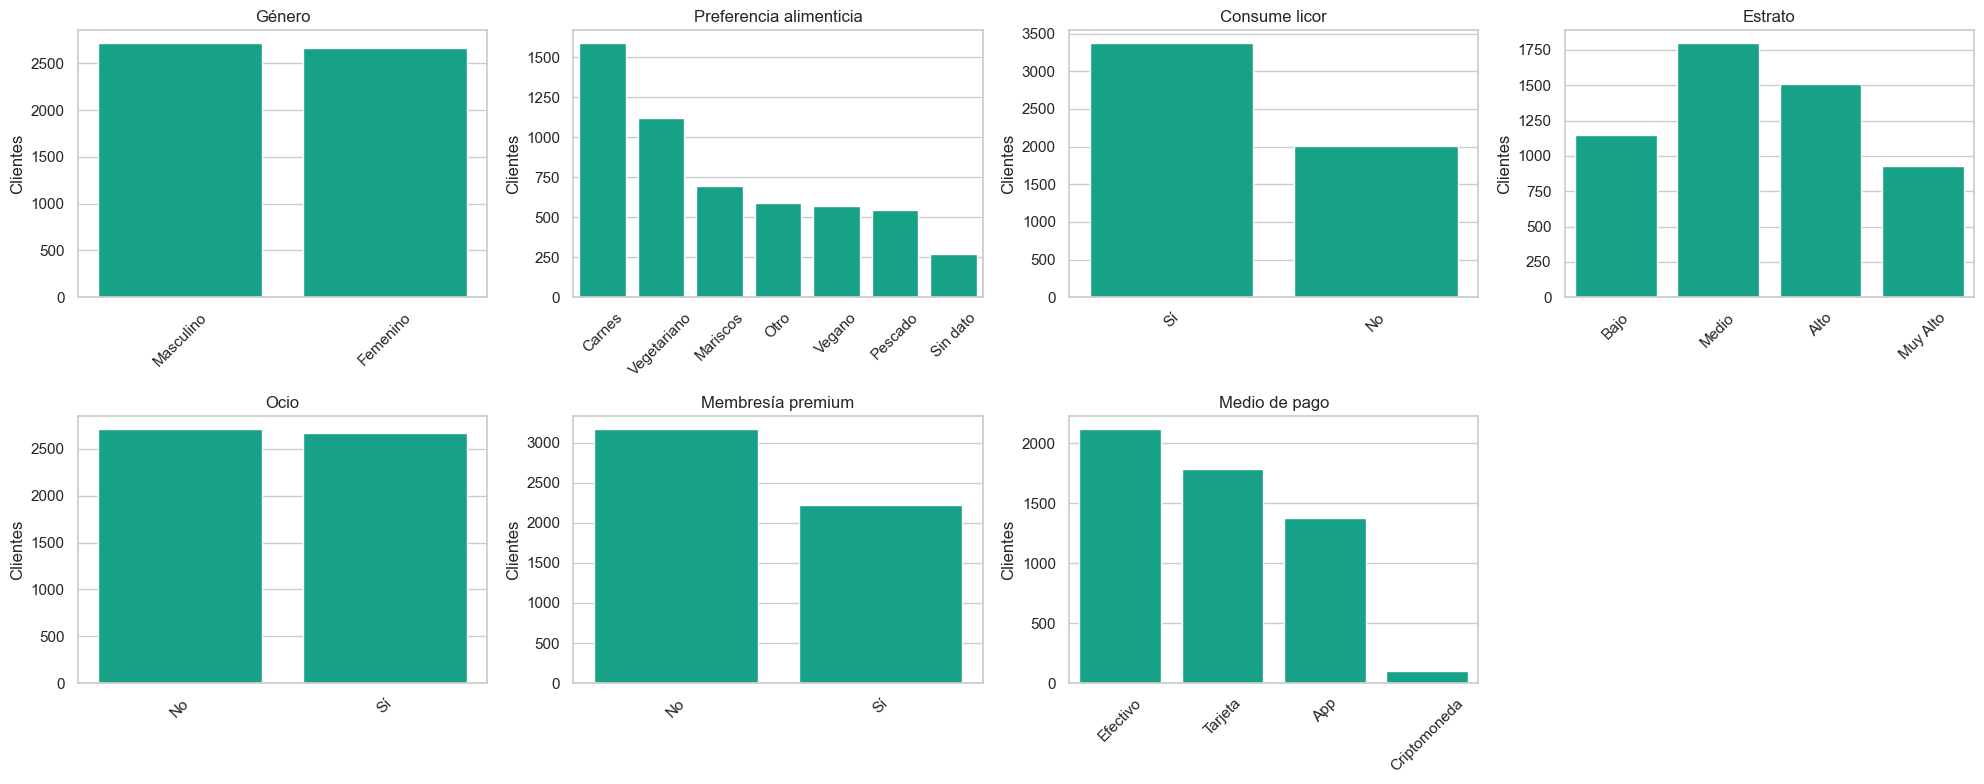

In [30]:
fig, ejes = plt.subplots(2, 4, figsize=(20, 8))
ejes = ejes.flatten()

for i, col in enumerate(columnas_categoricas):
    if col == 'estrato_socioeconomico':
        orden = ORDEN_ESTRATO                            # orden lógico
    else:
        orden = df_limpio[col].value_counts().index      # de mayor a menor
    sns.countplot(data=df_limpio, x=col, order=orden, ax=ejes[i], color='#00b894')
    ejes[i].set_title(NOMBRES[col])
    ejes[i].tick_params(axis='x', rotation=45)
    ejes[i].set_xlabel('')
    ejes[i].set_ylabel('Clientes')

ejes[-1].axis('off')   # el último cuadro queda vacío
plt.tight_layout()
plt.show()

**Interpretación:** confirma las tablas. Género y ocio están equilibrados, Carnes lidera entre las preferencias, el efectivo es el pago más usado y el estrato Medio es el más numeroso.

### 7.3 Detección de outliers (boxplots)
La caja va del percentil 25 al 75, la línea es la mediana y los puntos fuera de los bigotes son valores atípicos.

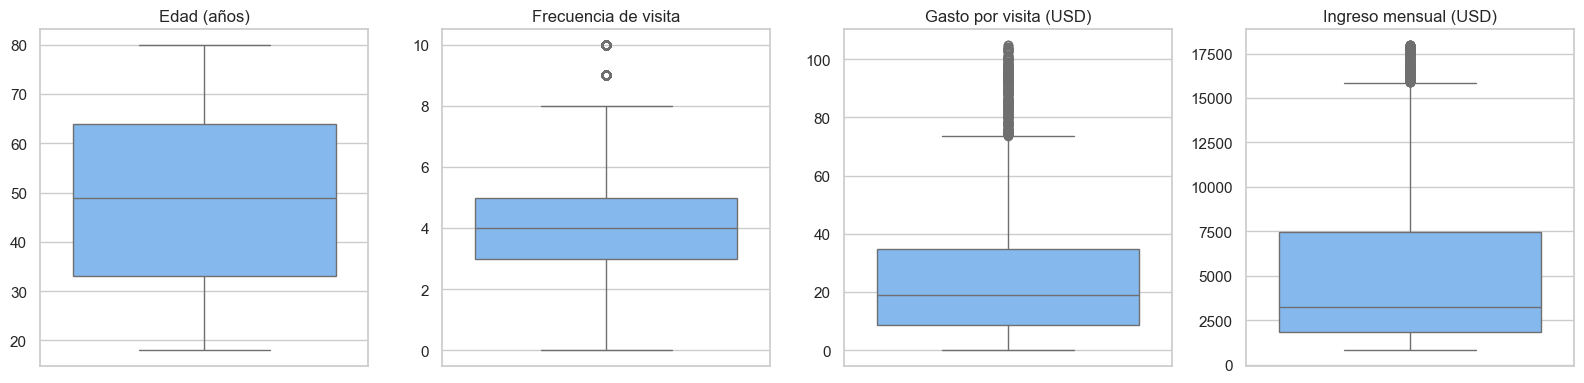

In [31]:
fig, ejes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df_limpio[col], ax=ejes[i], color='#74b9ff')
    ejes[i].set_title(NOMBRES[col])
    ejes[i].set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretación:**
- `edad` no tiene outliers una vez limpiada.
- En gasto e ingresos hay muchos puntos arriba del bigote: son clientes de alto gasto e ingresos, valores legítimos que conservamos.
- En `frecuencia_visita` los valores 9 y 10 aparecen como atípicos, pero son posibles.

### 7.4 Correlación entre variables numéricas
Va de -1 (relación inversa) a 1 (directa); cerca de 0 no hay relación lineal.

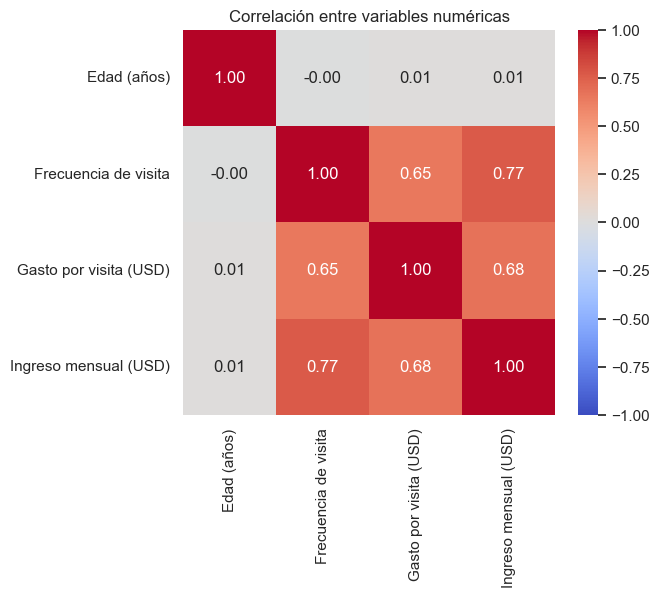

In [32]:
plt.figure(figsize=(6, 5))
correlaciones = df_limpio[columnas_numericas].corr().rename(index=NOMBRES, columns=NOMBRES)
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

**Interpretación:**
- `ingresos_mensuales` es lo que más se relaciona con el comportamiento: 0,77 con la frecuencia de visita y 0,68 con el gasto.
- `frecuencia_visita` y `promedio_gasto_comida` también van juntas (0,65).
- `edad` no se relaciona con gasto, frecuencia ni ingresos (0,00 a 0,01). En P4 vemos que sí importa para el licor.
- Correlación no implica causalidad: los ingresos y el estrato están detrás de casi todo.

### 7.5 Ingresos vs. gasto en comida (scatterplot)
Cada punto es un cliente, coloreado por estrato.

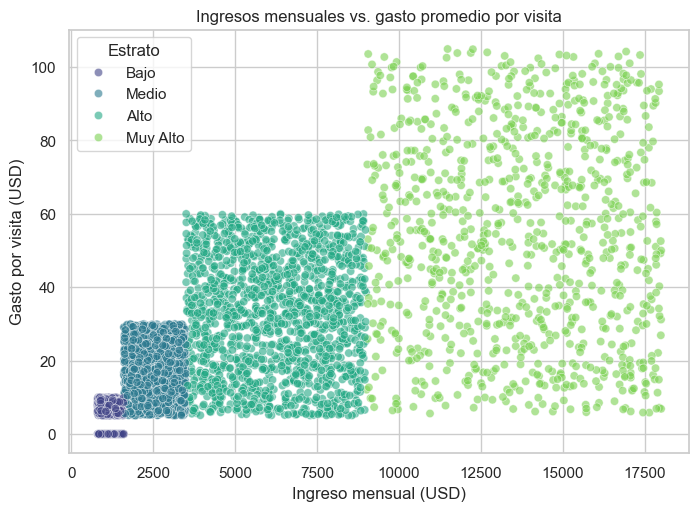

In [33]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df_limpio, x='ingresos_mensuales', y='promedio_gasto_comida',
                hue='estrato_socioeconomico', hue_order=ORDEN_ESTRATO, alpha=0.6, palette='viridis')
plt.title('Ingresos mensuales vs. gasto promedio por visita')
plt.xlabel('Ingreso mensual (USD)')
plt.ylabel('Gasto por visita (USD)')
plt.gca().get_legend().set_title('Estrato')
plt.show()

**Interpretación:** a mayores ingresos, mayor gasto por visita. Los estratos forman franjas: Bajo y Medio con ingresos y gasto bajos, Alto y Muy Alto con ingresos y gasto altos. La dispersión del gasto crece con los ingresos.

### 7.6 Gasto según estrato y según preferencia alimenticia
Comparamos el gasto entre grupos: boxplot por estrato y promedio por preferencia.

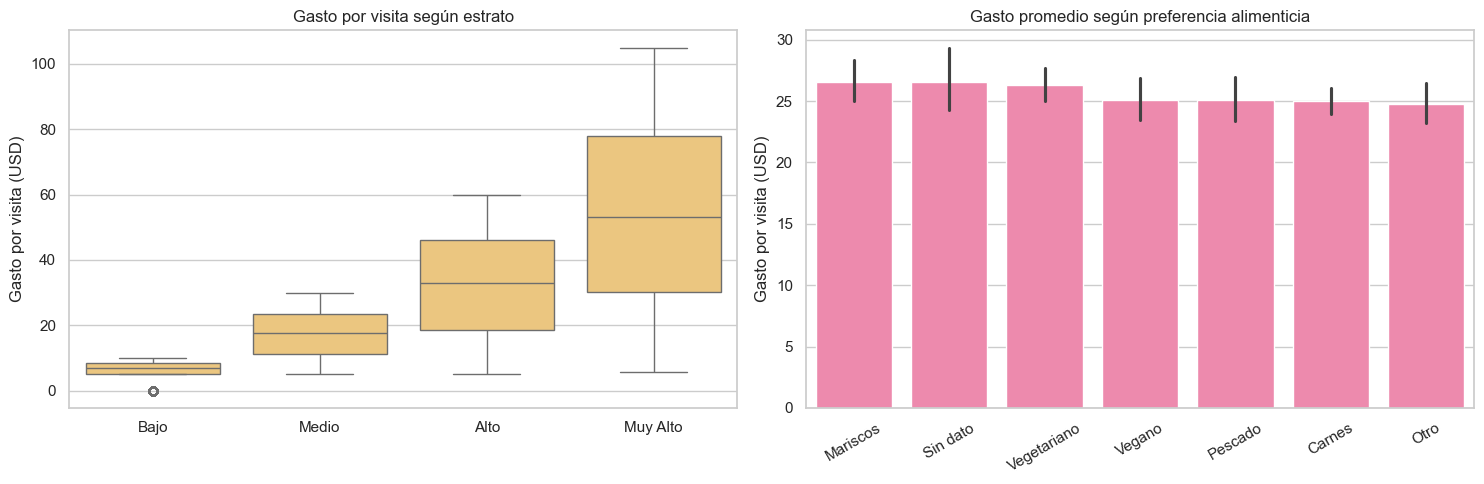

In [34]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_limpio, x='estrato_socioeconomico', y='promedio_gasto_comida', order=ORDEN_ESTRATO,
            ax=ejes[0], color='#fdcb6e')
ejes[0].set_title('Gasto por visita según estrato')
ejes[0].set_xlabel('')
ejes[0].set_ylabel('Gasto por visita (USD)')

orden_pref = df_limpio.groupby('preferencias_alimenticias')['promedio_gasto_comida'].mean().sort_values(ascending=False).index
sns.barplot(data=df_limpio, x='preferencias_alimenticias', y='promedio_gasto_comida', order=orden_pref,
            ax=ejes[1], color='#fd79a8', seed=0)
ejes[1].set_title('Gasto promedio según preferencia alimenticia')
ejes[1].tick_params(axis='x', rotation=30)
ejes[1].set_xlabel('')
ejes[1].set_ylabel('Gasto por visita (USD)')

plt.tight_layout()
plt.show()

**Interpretación:**
- **El estrato determina el gasto:** la mediana por visita sube de $6,84 (Bajo) a $17,58 (Medio), $32,96 (Alto) y $53,11 (Muy Alto).
- **La preferencia casi no cambia el gasto:** todos los grupos gastan entre $24,8 y $26,6 en promedio. Lo que el cliente quiere comer y lo que puede gastar son independientes, y por eso conviene segmentar por ambas.

## 8. Análisis e interpretación de hallazgos  *(Avance #3)*

Respondemos preguntas de negocio con la base unificada del Avance #2 (`Avance_API_Yelp.ipynb`): cada cliente limpio junto con la información de Yelp de su tipo de comida.

| # | Pregunta de negocio |
|---|---|
| P1 | ¿Qué características distinguen a los clientes que más gastan? |
| P2 | ¿La preferencia alimenticia se relaciona con el estrato socioeconómico? |
| P3 | ¿Qué otras variables están relacionadas entre sí? *(mapa de asociaciones)* |
| P4 | ¿Quién consume licor? |
| P5 | ¿La oferta de Chicago cubre lo que los clientes **prefieren comer**? |
| P6 | ¿La oferta de Chicago cubre lo que los clientes **pueden pagar**? |
| P7 | ¿Cómo segmentamos a los clientes según su valor y cómo es cada segmento? |
| P8 | ¿Dónde está el potencial de crecimiento? |

### 8.0 Cargar la base unificada
Leemos `data/base_unificada_chicago.csv` y comprobamos que son los mismos clientes del Avance #1, con exactamente los mismos datos. También leemos la tabla de restaurantes de Yelp para las preguntas de precio.

In [35]:
# Base unificada: clientes limpios del Avance #1 + información de Yelp del Avance #2
df_int = pd.read_csv(RUTA_DATA / 'base_unificada_chicago.csv')

# ¿Son los mismos clientes, con los mismos datos, que limpiamos en el Avance #1?
ordenar = lambda df: df.sort_values('id_persona').reset_index(drop=True)
mismos_datos = ordenar(df_int[df_limpio.columns]).equals(ordenar(df_limpio))
print('Clientes en la base unificada:', len(df_int))
print('Mismos clientes y mismos datos que en el Avance #1:', mismos_datos)

df_int.head()

Clientes en la base unificada: 5384
Mismos clientes y mismos datos que en el Avance #1: True


,id_persona,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,tipo_de_pago_mas_usado,ingresos_mensuales,grupo_preferencia,n_restaurantes,rating_prom,clientes_por_restaurante,indice_cobertura
0,3456521319,61,Masculino,Chicago,Medio,2,23.02,Sí,Sí,Vegetariano,No,Efectivo,2838,Vegetariano/Vegano,2.0,4.100000,847.000000,0.026486
1,2916502228,44,Femenino,Chicago,Bajo,3,5.07,No,Sí,Mariscos,No,App,1365,Mariscos y pescado,21.0,4.409524,59.142857,0.379308
2,5736368501,54,Femenino,Chicago,Alto,5,34.35,No,Sí,Carnes,Sí,Tarjeta,7133,Carnes,32.0,4.312500,49.656250,0.451773
3,9718391309,70,Femenino,Chicago,Bajo,1,6.59,No,Sí,Vegetariano,No,Tarjeta,1205,Vegetariano/Vegano,2.0,4.100000,847.000000,0.026486
4,9148064715,79,Masculino,Chicago,Muy Alto,8,78.02,No,Sí,Pescado,Sí,App,17625,Mariscos y pescado,21.0,4.409524,59.142857,0.379308


In [36]:
# Restaurantes de Yelp (los usamos para las preguntas de precio y las joyas ocultas)
df_yelp = pd.read_csv(RUTA_DATA / 'yelp_restaurantes_chicago.csv')

# Grupos de edad (los usamos más adelante)
df_int['grupo_edad'] = pd.cut(df_int['edad'], bins=[17, 30, 50, 70, 100], labels=['18-30', '31-50', '51-70', '71+'])

df_int['grupo_preferencia'].value_counts()

grupo_preferencia
Vegetariano/Vegano    1694
Carnes                1589
Mariscos y pescado    1242
Otro                   591
Sin dato               268
Name: count, dtype: int64

### P1 · ¿Qué características distinguen a los clientes que más gastan?

Comparamos el gasto por visita entre grupos con la prueba de **Kruskal-Wallis**, que no exige que el gasto tenga forma de campana. Si el p-valor es menor a 0,05, la diferencia es significativa.

In [37]:
variables = ['estrato_socioeconomico', 'membresia_premium', 'consume_licor', 'ocio',
             'genero', 'tipo_de_pago_mas_usado', 'preferencias_alimenticias', 'grupo_edad']

filas = []
for variable in variables:
    p_valor = p_valor_kruskal(df_int, variable, 'promedio_gasto_comida')   # ¿el gasto cambia según esta variable?

    medianas = df_int.groupby(variable, observed=True)['promedio_gasto_comida'].median()
    filas.append({'variable': variable, 'p_valor': p_valor,
                  'grupo_que_mas_gasta': medianas.idxmax(), 'mediana_mayor': medianas.max(),
                  'grupo_que_menos_gasta': medianas.idxmin(), 'mediana_menor': medianas.min()})

resultados_p1 = pd.DataFrame(filas).sort_values('p_valor')
resultados_p1['diferencia_significativa'] = np.where(resultados_p1['p_valor'] < 0.05, 'Sí', 'No')
resultados_p1['p_valor'] = resultados_p1['p_valor'].round(4)   # 0.0 significa "menor a 0.0001"
resultados_p1

,variable,p_valor,grupo_que_mas_gasta,mediana_mayor,grupo_que_menos_gasta,mediana_menor,diferencia_significativa
0,estrato_socioeconomico,0.0000,Muy Alto,53.110,Bajo,6.845,Sí
1,membresia_premium,0.0000,Sí,35.240,No,11.200,Sí
3,ocio,0.2571,Sí,19.340,No,18.700,No
6,preferencias_alimenticias,0.4526,Mariscos,20.490,Carnes,18.250,No
4,genero,0.6401,Masculino,19.130,Femenino,19.010,No
5,tipo_de_pago_mas_usado,0.7728,Efectivo,19.335,Criptomoneda,17.020,No
7,grupo_edad,0.8352,31-50,19.745,18-30,18.490,No
2,consume_licor,0.8487,No,19.450,Sí,18.840,No


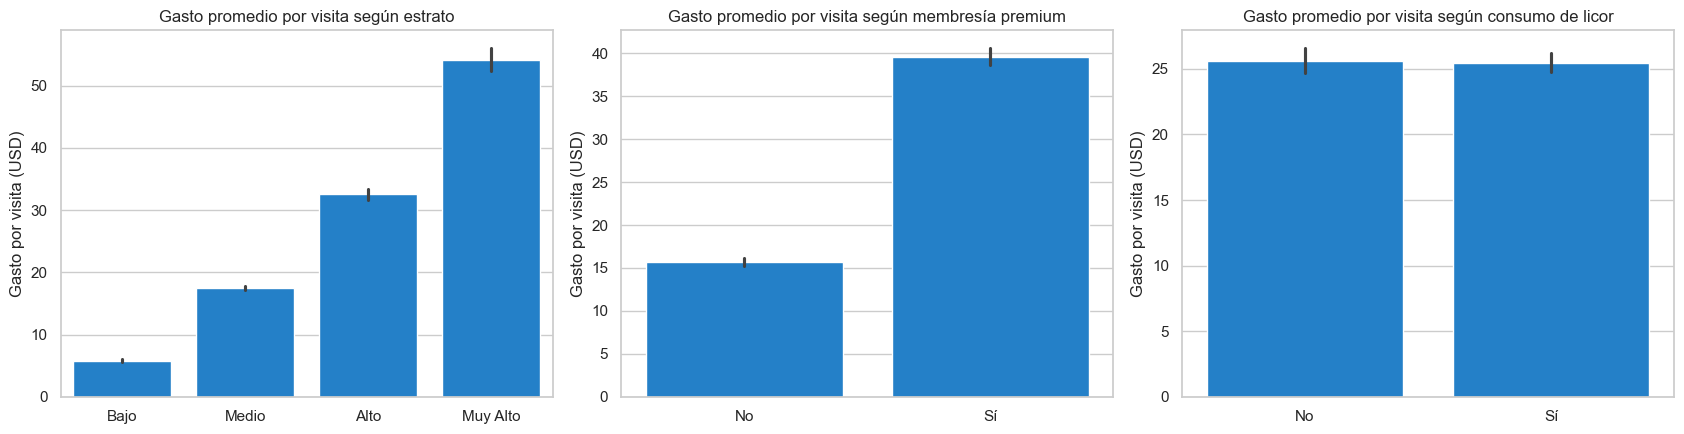

In [38]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.barplot(data=df_int, x='estrato_socioeconomico', y='promedio_gasto_comida', order=ORDEN_ESTRATO, ax=ejes[0], color='#0984e3', seed=0)
sns.barplot(data=df_int, x='membresia_premium', y='promedio_gasto_comida', order=['No', 'Sí'], ax=ejes[1], color='#0984e3', seed=0)
sns.barplot(data=df_int, x='consume_licor', y='promedio_gasto_comida', order=['No', 'Sí'], ax=ejes[2], color='#0984e3', seed=0)

ejes[0].set_title('Gasto promedio por visita según estrato')
ejes[1].set_title('Gasto promedio por visita según membresía premium')
ejes[2].set_title('Gasto promedio por visita según consumo de licor')

for eje in ejes:
    eje.set_ylabel('Gasto por visita (USD)')
    eje.set_xlabel('')

plt.tight_layout()
plt.show()

**Interpretación de P1:**
- Solo el estrato y la membresía premium se asocian a diferencias reales de gasto (p-valores menores a 0,0001).
- Género, licor, ocio, medio de pago, preferencia alimenticia y grupo de edad no muestran diferencias significativas (p entre 0,26 y 0,85). Diseñar campañas de monto con estas variables no tendría respaldo.
- Ojo con la membresía: depende casi por completo del estrato. Las siguientes celdas verifican si influye por sí sola.

In [39]:
# ¿La membresía premium influye por sí sola, o solo refleja el estrato?
# Comparamos el gasto mediano de premium vs. no premium DENTRO de cada estrato.
df_int.groupby(['estrato_socioeconomico', 'membresia_premium'])['promedio_gasto_comida'].agg(['median', 'count']).round(2).unstack().reindex(ORDEN_ESTRATO)

median        count      
membresia_premium          No     Sí    No    Sí
estrato_socioeconomico                          
Bajo                     6.84   8.37  1140     8
Medio                   17.58  17.69  1563   235
Alto                    32.76  32.96   422  1089
Muy Alto                46.25  53.52    44   883

In [40]:
for estrato in ORDEN_ESTRATO:
    dentro_del_estrato = df_int[df_int['estrato_socioeconomico'] == estrato]
    premium = dentro_del_estrato.loc[dentro_del_estrato['membresia_premium'] == 'Sí', 'promedio_gasto_comida']
    no_premium = dentro_del_estrato.loc[dentro_del_estrato['membresia_premium'] == 'No', 'promedio_gasto_comida']

    if min(len(premium), len(no_premium)) < 30:
        print(f'Estrato {estrato}: solo {min(len(premium), len(no_premium))} clientes en uno de los grupos -> no alcanza para comparar')
    else:
        print(f'Estrato {estrato}: premium vs. no premium -> p-valor = {stats.kruskal(premium, no_premium).pvalue:.2f}')

Estrato Bajo: solo 8 clientes en uno de los grupos -> no alcanza para comparar
Estrato Medio: premium vs. no premium -> p-valor = 0.68
Estrato Alto: premium vs. no premium -> p-valor = 0.88
Estrato Muy Alto: premium vs. no premium -> p-valor = 0.22


**Interpretación:** al comparar clientes del mismo estrato, la membresía premium no cambia el gasto de forma significativa. En Medio la mediana es $17,69 (premium) vs. $17,58 (p = 0,68), en Alto $32,96 vs. $32,76 (p = 0,88) y en Muy Alto $53,52 vs. $46,25 (p = 0,22, con apenas 44 clientes no premium). En Bajo hay solo 8 clientes premium, así que no se puede comparar.

La diferencia inicial se debía a que los premium son casi todos de estratos altos. **La membresía parece reflejar el nivel socioeconómico y no causar un mayor gasto.** Para saber si promoverla aumenta el gasto habría que probarlo con un experimento.

### P2 · ¿La preferencia alimenticia se relaciona con el estrato socioeconómico?

Hipótesis natural: "la gente de estratos altos prefiere otra comida". La probamos con:
- una tabla con el porcentaje de cada preferencia dentro de cada estrato;
- la prueba de **chi-cuadrado** (p-valor menor a 0,05 = hay relación);
- la **V de Cramér**, que mide qué tan fuerte es la relación entre dos variables categóricas, de 0 a 1 (menos de 0,1 despreciable, 0,1 a 0,3 débil, 0,3 a 0,5 moderada, más de 0,5 fuerte).

Como la V de Cramér no viene en las librerías, armamos una función chica:

In [41]:
def cramer_v(a, b):
    tabla = pd.crosstab(a, b)                                          # tabla de conteos cruzados
    chi2, p_valor, grados, esperados = stats.chi2_contingency(tabla)   # prueba de chi-cuadrado
    n = tabla.values.sum()                                             # total de personas
    return (chi2 / (n * (min(tabla.shape) - 1))) ** 0.5                # fórmula de la V de Cramér

preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Sin dato,Vegano,Vegetariano
estrato_socioeconomico,,,,,,,
Bajo,31.3,13.0,10.5,10.4,4.2,10.3,20.4
Medio,29.9,12.5,10.9,9.8,5.6,10.4,21.0
Alto,29.4,12.6,11.7,10.4,4.8,10.7,20.4
Muy Alto,26.9,14.2,10.5,10.1,5.1,11.3,21.9


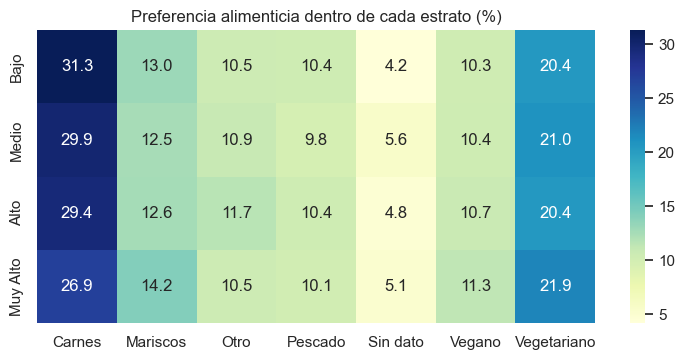

In [42]:
pref_por_estrato = tabla_porcentajes(df_int['estrato_socioeconomico'], df_int['preferencias_alimenticias'], ORDEN_ESTRATO)
display(pref_por_estrato)

plt.figure(figsize=(9, 3.8))
sns.heatmap(pref_por_estrato, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Preferencia alimenticia dentro de cada estrato (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

In [43]:
tabla_pref_estrato = pd.crosstab(df_int['estrato_socioeconomico'], df_int['preferencias_alimenticias'])
chi2, p_valor, grados, esperados = stats.chi2_contingency(tabla_pref_estrato)

print(f"Preferencia alimenticia vs. estrato: p-valor = {p_valor:.2f} | V de Cramér = {cramer_v(df_int['estrato_socioeconomico'], df_int['preferencias_alimenticias']):.3f}")
print(f"Grupo de preferencia vs. estrato:    p-valor = {stats.chi2_contingency(pd.crosstab(df_int['estrato_socioeconomico'], df_int['grupo_preferencia']))[1]:.2f} | V de Cramér = {cramer_v(df_int['estrato_socioeconomico'], df_int['grupo_preferencia']):.3f}")

Preferencia alimenticia vs. estrato: p-valor = 0.90 | V de Cramér = 0.026
Grupo de preferencia vs. estrato:    p-valor = 0.62 | V de Cramér = 0.025


**Interpretación de P2:**
- **La respuesta es no:** preferencia y estrato son prácticamente independientes. Chi-cuadrado p = 0,90 y V de Cramér de 0,026 (despreciable). Con las preferencias agrupadas en 4 grupos da igual (p = 0,62; V = 0,025).
- En todos los estratos el reparto es parecido: Carnes entre 27% y 31%, Vegetariano entre 20% y 22%, Mariscos y Pescado juntos entre 22% y 24%. Las diferencias (por ejemplo, Carnes 26,9% en Muy Alto vs. 31,3% en Bajo) entran en lo esperable por azar.
- El estrato no permite adivinar qué come una persona: la demanda vegetariana/vegana existe en todos los niveles (30,7% a 33,2%). **El contenido de una campaña y su presupuesto son dos decisiones independientes.**

### P3 · ¿Qué otras variables están relacionadas entre sí? *(mapa de asociaciones)*

Calculamos la V de Cramér para todas las combinaciones de variables categóricas y la mostramos en un mapa de calor (más oscuro = relación más fuerte). Sirve para ver rápido qué vale la pena mirar.

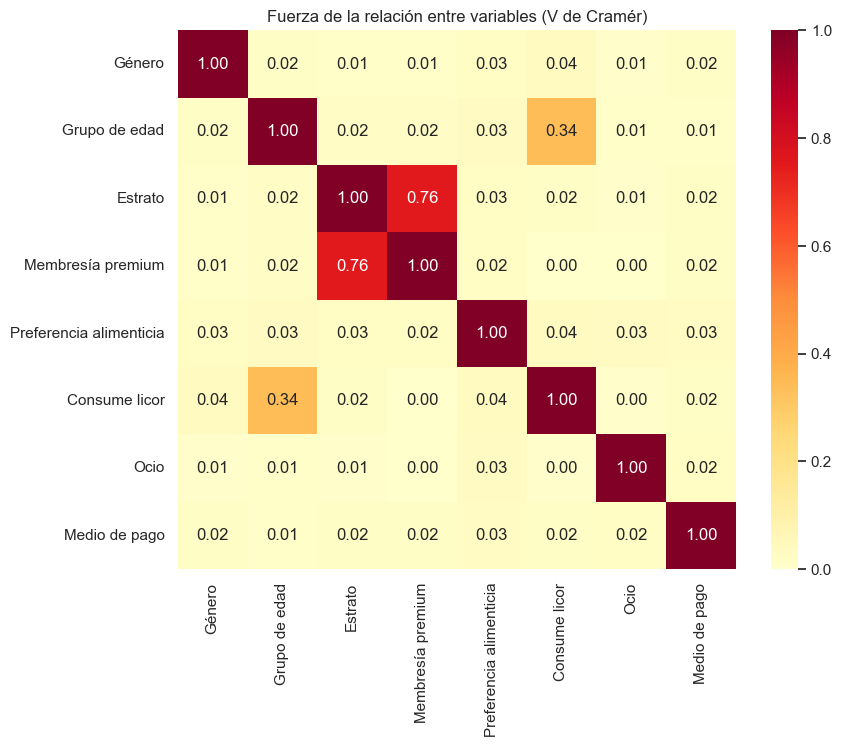

In [44]:
variables_cat = ['genero', 'grupo_edad', 'estrato_socioeconomico', 'membresia_premium', 'preferencias_alimenticias',
                 'consume_licor', 'ocio', 'tipo_de_pago_mas_usado']

matriz_v = pd.DataFrame(index=variables_cat, columns=variables_cat, dtype=float)
for a in variables_cat:
    for b in variables_cat:
        matriz_v.loc[a, b] = cramer_v(df_int[a], df_int[b])

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_v.rename(index=NOMBRES, columns=NOMBRES), annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Fuerza de la relación entre variables (V de Cramér)')
plt.show()

**Interpretación de P3:**
- De 28 pares, solo dos tienen una relación clara:
  1. **Estrato y membresía premium** (V = 0,76, fuerte): la membresía refleja el estrato.
  2. **Edad y consumo de licor** (V = 0,34, moderada): es nueva y la vemos en P4.
- Todo lo demás está por debajo de 0,05: género, preferencia, medio de pago y ocio no se relacionan con ninguna otra variable, así que no sirven para segmentar.
- Al probar tantos pares alguno podría salir significativo por azar, pero estas dos están muy lejos del ruido.

### P4 · ¿Quién consume licor?

El mapa mostró una relación entre edad y consumo de licor. La miramos por grupo de edad y después edad por edad.

In [45]:
licor_por_edad = tabla_porcentajes(df_int['grupo_edad'], df_int['consume_licor'])
licor_por_edad['clientes'] = df_int['grupo_edad'].value_counts()
licor_por_edad

consume_licor,No,Sí,clientes
grupo_edad,,,
18-30,9.6,90.4,1135
31-50,48.5,51.5,1746
51-70,34.3,65.7,1675
71+,58.0,42.0,828


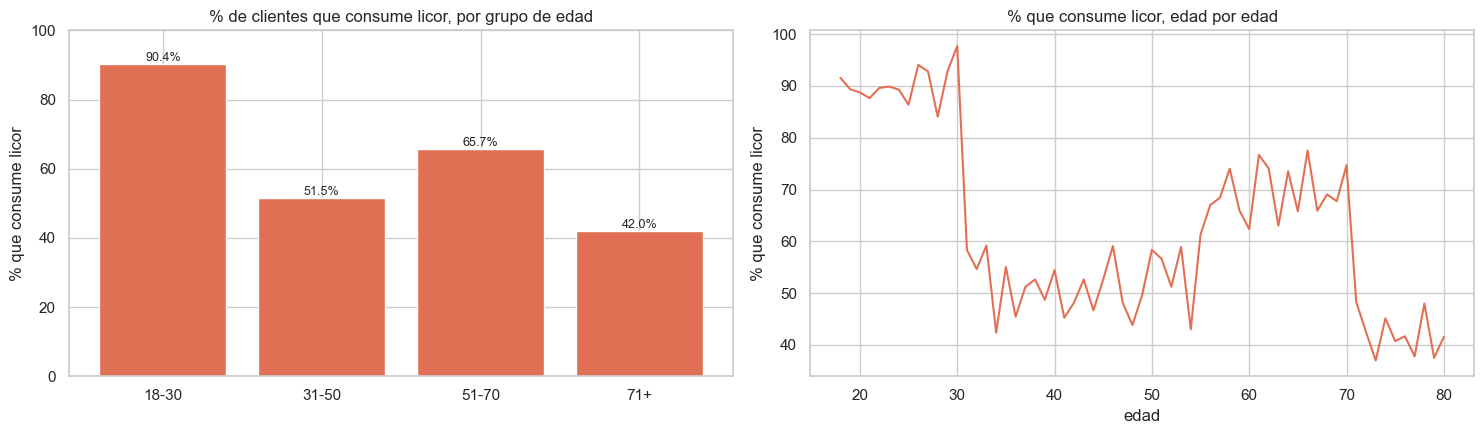

In [46]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.5))

barras = ejes[0].bar(licor_por_edad.index.astype(str), licor_por_edad['Sí'], color='#e17055')
ejes[0].bar_label(barras, fmt='%.1f%%', fontsize=9)
ejes[0].set_title('% de clientes que consume licor, por grupo de edad')
ejes[0].set_ylim(0, 100)
ejes[0].set_ylabel('% que consume licor')

# edad por edad: (consume_licor == 'Sí') vale True/False; el promedio de True/False es la proporción
licor_edad_por_edad = (df_int['consume_licor'] == 'Sí').groupby(df_int['edad']).mean() * 100
ejes[1].plot(licor_edad_por_edad.index, licor_edad_por_edad.values, color='#e17055')
ejes[1].set_title('% que consume licor, edad por edad')
ejes[1].set_xlabel('edad')
ejes[1].set_ylabel('% que consume licor')

plt.tight_layout()
plt.show()

In [47]:
# Los escalones del gráfico: el % que consume licor justo antes y después de los 30 y de los 70 años
licor_edad_por_edad.loc[[29, 30, 31, 32, 69, 70, 71, 72]].round(1)

edad
29    92.8
30    97.7
31    58.3
32    54.7
69    67.7
70    74.7
71    48.3
72    42.5
Name: consume_licor, dtype: float64

In [48]:
# ¿Y el estrato? Comparamos con lo que pasaba con el estrato: el consumo de licor casi no cambia
print(tabla_porcentajes(df_int['estrato_socioeconomico'], df_int['consume_licor'], ORDEN_ESTRATO))

p_licor_estrato = stats.chi2_contingency(pd.crosstab(df_int['estrato_socioeconomico'], df_int['consume_licor']))[1]
print(f'\nLicor vs. estrato: p-valor = {p_licor_estrato:.2f}')

consume_licor             No    Sí
estrato_socioeconomico            
Bajo                    38.3  61.7
Medio                   36.6  63.4
Alto                    36.8  63.2
Muy Alto                38.3  61.7

Licor vs. estrato: p-valor = 0.69


In [49]:
# ¿La edad se relaciona con el gasto, la frecuencia o los ingresos?
for variable in ['promedio_gasto_comida', 'frecuencia_visita', 'ingresos_mensuales']:
    print(f"{variable} según grupo de edad: p-valor = {p_valor_kruskal(df_int, 'grupo_edad', variable):.2f}")

promedio_gasto_comida según grupo de edad: p-valor = 0.84
frecuencia_visita según grupo de edad: p-valor = 0.95
ingresos_mensuales según grupo de edad: p-valor = 0.50


In [50]:
# La edad legal para tomar alcohol en EE. UU. es 21: ¿cuántos clientes de 21 a 30 años hay y cuántos consumen?
de_21_a_30 = df_int[(df_int['edad'] >= 21) & (df_int['edad'] <= 30)]
print(f"Clientes de 21 a 30 años: {len(de_21_a_30):,} | consumen licor: {(de_21_a_30['consume_licor'] == 'Sí').mean():.1%}")

Clientes de 21 a 30 años: 887 | consumen licor: 90.5%


**Interpretación de P4:**
- **El licor depende de la edad, no del estrato.** Entre 18 y 30 años consume el 90,4% (1.135 clientes, 21% de la base); baja a 51,5% (31-50), sube a 65,7% (51-70) y cae a 42,0% pasados los 70.
- Hay un escalón marcado: 98% a los 30 años y 58% a los 31 (75% a los 70 y 48% a los 71). Por estrato no cambia: entre 61,7% y 63,4% (p = 0,69).
- La edad no se relaciona con el gasto (p = 0,84), la frecuencia (p = 0,95) ni los ingresos (p = 0,50). Sirve para una sola cosa: saber a quién ofrecerle licor.
- Las campañas de bares y coctelería conviene dirigirlas por edad y no por nivel socioeconómico, pero **solo a partir de los 21 años**, que es la edad legal para tomar alcohol en EE. UU. El grupo de 21 a 30 años tiene 887 clientes y consume el 90,5%. En Chicago hay oferta: el 43% de los restaurantes de Yelp tiene categoría de bar.
- *Nota:* un cambio tan brusco entre los 30 y los 31 años es raro en datos reales, así que probablemente estos datos fueron generados por reglas. Conviene validarlo con datos reales.

### P5 · ¿La oferta de Chicago cubre lo que los clientes **prefieren comer**?

Por grupo de preferencia comparamos cuántos clientes lo prefieren contra cuántos restaurantes de Yelp lo ofrecen. La base unificada ya trae la oferta de cada grupo.

In [51]:
nombres_grupos = ['Carnes', 'Mariscos y pescado', 'Vegetariano/Vegano', 'Otro']

# Una fila por grupo: contamos clientes y tomamos los datos de Yelp que ya vienen en la base unificada
oferta = df_int.groupby('grupo_preferencia').agg(
    n_clientes=('id_persona', 'count'),
    gasto_prom=('promedio_gasto_comida', 'mean'),
    n_restaurantes=('n_restaurantes', 'first'),
    rating_prom=('rating_prom', 'first'),
    clientes_por_restaurante=('clientes_por_restaurante', 'first'),
    indice_cobertura=('indice_cobertura', 'first'),
).reindex(nombres_grupos).reset_index()
oferta['n_restaurantes'] = oferta['n_restaurantes'].astype(int)

oferta['pct_clientes'] = oferta['n_clientes'] / len(df_int) * 100            # sobre todos los clientes
oferta['pct_restaurantes'] = oferta['n_restaurantes'] / len(df_yelp) * 100   # sobre todos los restaurantes
oferta.round(2)

,grupo_preferencia,n_clientes,gasto_prom,n_restaurantes,rating_prom,clientes_por_restaurante,indice_cobertura,pct_clientes,pct_restaurantes
0,Carnes,1589,24.96,32,4.31,49.66,0.45,29.51,13.33
1,Mariscos y pescado,1242,25.92,21,4.41,59.14,0.38,23.07,8.75
2,Vegetariano/Vegano,1694,25.89,2,4.10,847.00,0.03,31.46,0.83
3,Otro,591,24.76,191,4.40,3.09,7.25,10.98,79.58


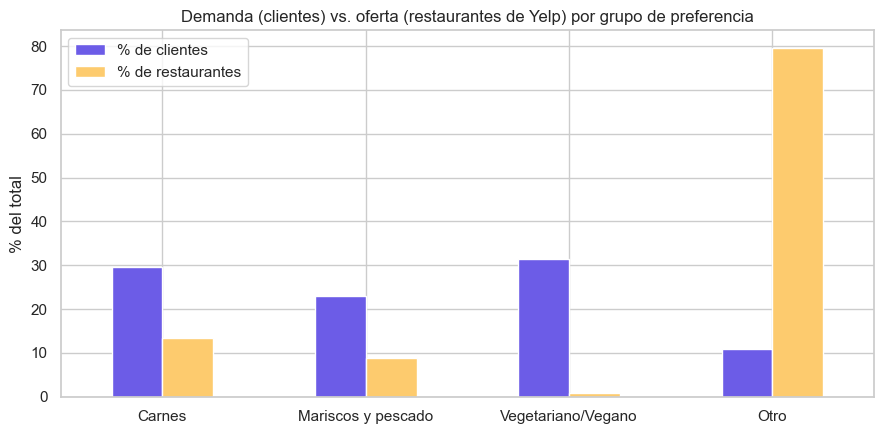

In [52]:
comparacion = oferta.set_index('grupo_preferencia')[['pct_clientes', 'pct_restaurantes']]
comparacion.plot(kind='bar', figsize=(9, 4.5), color=['#6c5ce7', '#fdcb6e'])
plt.title('Demanda (clientes) vs. oferta (restaurantes de Yelp) por grupo de preferencia')
plt.ylabel('% del total')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(['% de clientes', '% de restaurantes'])
plt.tight_layout()
plt.show()

**Interpretación de P5:**
- **Vegetariano/Vegano es el mayor desajuste.** Es el 31,5% de los clientes (el grupo más grande) pero solo 2 de los 240 restaurantes (0,8%). Son 847 clientes por restaurante, contra 50 en Carnes y 59 en Mariscos y pescado. El índice de cobertura es 0,03.
- Esos dos restaurantes tienen el rating promedio más bajo (4,10, contra 4,31 en Carnes y 4,41 en Mariscos y pescado).
- Carnes y Mariscos y pescado también están subatendidos (índices de 0,45 y 0,38), pero mucho menos.
- La oferta se concentra en Otro (191 restaurantes, 80%), donde pesan los bares (43% del total).
- Los 268 clientes `Sin dato` no tienen un grupo para cruzar con Yelp. Además, 6 restaurantes cuentan en Carnes y en Mariscos a la vez (por ejemplo, Penumbra), por eso los porcentajes de restaurantes suman un poco más de 100%.

### P6 · ¿La oferta de Chicago cubre lo que los clientes **pueden pagar**?

Además de qué quieren comer, importa cuánto pueden gastar. Usamos los rangos aproximados de Yelp: `$` hasta 10 USD, `$$` de 11 a 30, `$$$` de 31 a 60 y `$$$$` más de 60. Ubicamos a cada cliente en el rango de su gasto por visita y lo comparamos con la oferta.

In [53]:
# Solo los clientes que gastan algo (los que tienen gasto 0 no visitan)
con_gasto = df_int[df_int['promedio_gasto_comida'] > 0].copy()
con_gasto['rango_precio'] = pd.cut(con_gasto['promedio_gasto_comida'], bins=RANGOS_PRECIO, labels=ETIQUETAS_PRECIO)

pct_clientes = con_gasto['rango_precio'].value_counts(normalize=True) * 100

# Solo los restaurantes que informan su precio (a 96 les falta)
restaurantes_con_precio = df_yelp[df_yelp['precio'].notna()]
pct_restaurantes = restaurantes_con_precio['precio'].value_counts(normalize=True) * 100

tabla_precio = pd.DataFrame({'% de clientes': pct_clientes, '% de restaurantes': pct_restaurantes}).reindex(ETIQUETAS_PRECIO).round(1)
tabla_precio

,% de clientes,% de restaurantes
$,28.2,0.7
$$,41.6,64.6
$$$,22.4,26.4
$$$$,7.8,8.3


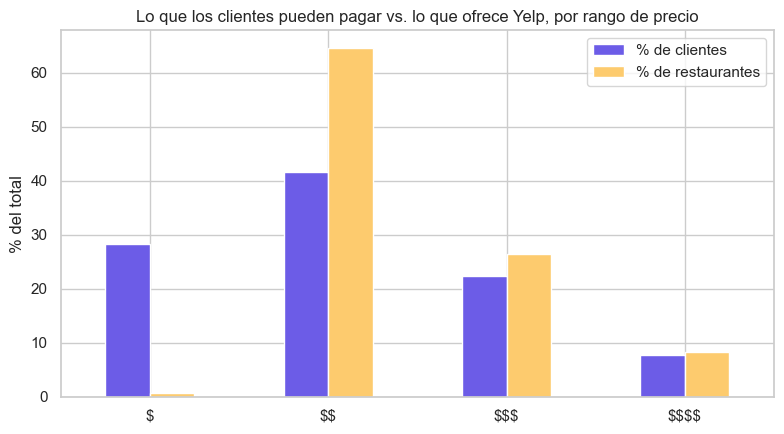

In [54]:
tabla_precio.plot(kind='bar', figsize=(8, 4.5), color=['#6c5ce7', '#fdcb6e'])
plt.title('Lo que los clientes pueden pagar vs. lo que ofrece Yelp, por rango de precio')
plt.ylabel('% del total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
# ¿Qué rango de precio le corresponde a cada estrato? (% dentro de cada estrato)
tabla_porcentajes(con_gasto['estrato_socioeconomico'], con_gasto['rango_precio'], ORDEN_ESTRATO)

rango_precio,$,$$,$$$,$$$$
estrato_socioeconomico,,,,
Bajo,100.0,0.0,0.0,0.0
Medio,20.6,79.4,0.0,0.0
Alto,9.8,34.0,56.3,0.0
Muy Alto,4.4,20.4,31.8,43.4


In [56]:
# Las "joyas ocultas" de Yelp, con el mismo criterio que en Avance_API_Yelp (sección 5.4): ¿en qué rango de precio están?
mediana_resenas = df_yelp['review_count'].median()
con_resenas_suficientes = df_yelp[df_yelp['review_count'] >= 30]      # al menos 30 reseñas
joyas = con_resenas_suficientes[(con_resenas_suficientes['rating'] >= 4.6) & (con_resenas_suficientes['review_count'] < mediana_resenas)]

print(f'Joyas ocultas: {len(joyas)}')
joyas['precio'].fillna('Sin dato').value_counts()

Joyas ocultas: 24


precio
Sin dato    19
$$           4
$$$$         1
Name: count, dtype: int64

**Interpretación de P6:**
- **Hay una brecha en el extremo económico.** El 28% de los clientes que visitan gasta hasta $10 (`$`), pero solo 1 de los 144 restaurantes con precio (0,7%) es `$`. En cambio `$$` concentra el 65% de los restaurantes frente al 42% de los clientes.
- **El estrato define el rango:** el 100% del estrato Bajo gasta en `$`, el 79% del Medio está en `$$`, el 56% del Alto en `$$$` y el 43% del Muy Alto llega a `$$$$`.
- Para los clientes de Bajo valor hay dos explicaciones posibles: que su presupuesto no alcance o que casi no haya restaurantes de su rango de precio. Las dos llevan a lo mismo: promociones con descuentos, combos o delivery en restaurantes `$$`, y sumar restaurantes económicos como aliados.
- **Joyas ocultas:** 24 restaurantes con rating de 4,6 o más, al menos 30 reseñas y menos reseñas que la mediana. 19 de los 24 no informan precio, así que conviene consultarlo antes de promocionarlos.
- **Cautela:** los rangos de Yelp son aproximados, al 40% de los restaurantes les falta el precio y la muestra favorece a locales populares, que rara vez son los más baratos. La brecha puede estar exagerada, pero la dirección es clara.

### P7 · ¿Cómo segmentamos a los clientes según su valor y cómo es cada segmento?

Creamos un **índice de valor** = `promedio_gasto_comida × frecuencia_visita`. Es relativo: sirve para ordenar clientes, no es un monto en dólares.

Segmentos:
- **Inactivo:** `frecuencia_visita == 0`.
- **Alto valor:** el 25% de clientes activos con mayor índice.
- **Bajo valor:** el 25% de clientes activos con menor índice.
- **Valor medio:** el 50% restante.

In [57]:
df_int['indice_valor'] = df_int['promedio_gasto_comida'] * df_int['frecuencia_visita']

# Los umbrales se calculan solo entre los clientes activos (los que visitan)
activos = df_int[df_int['frecuencia_visita'] > 0]
q25 = activos['indice_valor'].quantile(0.25)
q75 = activos['indice_valor'].quantile(0.75)
print(f'Umbrales del índice de valor entre clientes activos: Q25 = {q25:.1f} | Q75 = {q75:.1f}')

Umbrales del índice de valor entre clientes activos: Q25 = 31.1 | Q75 = 192.7


In [58]:
# Asignamos el segmento con máscaras: primero "Valor medio" para todos y después corregimos
df_int['segmento'] = 'Valor medio'
df_int.loc[df_int['indice_valor'] >= q75, 'segmento'] = 'Alto valor'
df_int.loc[df_int['indice_valor'] <= q25, 'segmento'] = 'Bajo valor'
df_int.loc[df_int['frecuencia_visita'] == 0, 'segmento'] = 'Inactivo'

ORDEN_SEG = ['Alto valor', 'Valor medio', 'Bajo valor', 'Inactivo']
tabla_frecuencias(df_int['segmento']).reindex(ORDEN_SEG)

,conteo,porcentaje
segmento,,
Alto valor,1281,23.79
Valor medio,2561,47.57
Bajo valor,1281,23.79
Inactivo,261,4.85


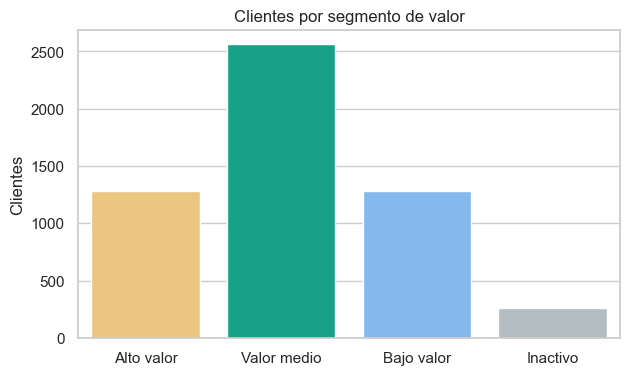

In [59]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_int, x='segmento', order=ORDEN_SEG, hue='segmento', legend=False,
              palette=['#00b894', '#74b9ff', '#fdcb6e', '#b2bec3'])
plt.title('Clientes por segmento de valor')
plt.xlabel('')
plt.ylabel('Clientes')
plt.show()

In [60]:
# Perfil numérico de cada segmento
perfil = df_int.groupby('segmento').agg(
    clientes=('id_persona', 'count'),
    gasto_medio=('promedio_gasto_comida', 'mean'),
    frecuencia_media=('frecuencia_visita', 'mean'),
    ingreso_medio=('ingresos_mensuales', 'mean'),
    edad_media=('edad', 'mean'),
)

# Porcentajes de "Sí" (premium y licor) por segmento
perfil['pct_premium'] = (df_int['membresia_premium'] == 'Sí').groupby(df_int['segmento']).mean() * 100
perfil['pct_licor'] = (df_int['consume_licor'] == 'Sí').groupby(df_int['segmento']).mean() * 100

# La categoría más frecuente en cada segmento
perfil['estrato_mas_comun'] = pd.crosstab(df_int['segmento'], df_int['estrato_socioeconomico']).idxmax(axis=1)
perfil['preferencia_mas_comun'] = pd.crosstab(df_int['segmento'], df_int['preferencias_alimenticias']).idxmax(axis=1)

perfil.reindex(ORDEN_SEG).round(1)

,clientes,gasto_medio,frecuencia_media,ingreso_medio,edad_media,pct_premium,pct_licor,estrato_mas_comun,preferencia_mas_comun
segmento,,,,,,,,,
Alto valor,1281,57.8,6.6,10287.9,48.7,85.5,61.4,Muy Alto,Carnes
Valor medio,2561,20.9,4.4,4774.8,48.7,40.1,63.5,Medio,Carnes
Bajo valor,1281,7.7,2.3,1787.3,48.5,7.2,63.8,Bajo,Carnes
Inactivo,261,0.0,0.0,1197.8,50.1,0.8,55.9,Bajo,Carnes


grupo_preferencia,Carnes,Mariscos y pescado,Otro,Sin dato,Vegetariano/Vegano
segmento,,,,,
Alto valor,27.6,23.7,10.2,5.3,33.1
Valor medio,29.4,23.0,11.4,5.3,30.9
Bajo valor,31.5,23.2,10.5,4.1,30.7
Inactivo,30.3,19.5,13.0,4.2,33.0


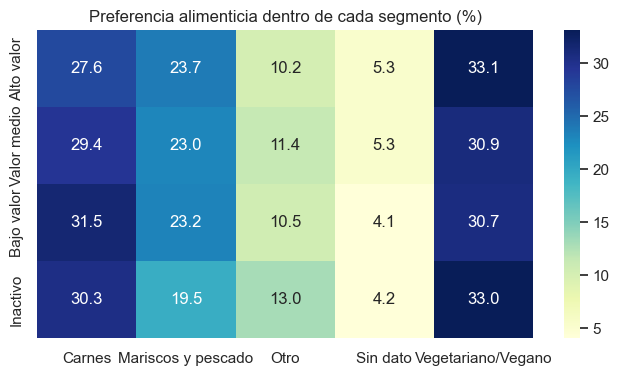

In [61]:
# Composición de cada segmento por grupo de preferencia (% dentro del segmento)
composicion = tabla_porcentajes(df_int['segmento'], df_int['grupo_preferencia'], ORDEN_SEG)
display(composicion)

plt.figure(figsize=(8, 4))
sns.heatmap(composicion, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Preferencia alimenticia dentro de cada segmento (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

,% de clientes,% del valor total
segmento,,
Alto valor,23.8,66.2
Valor medio,47.6,30.8
Bajo valor,23.8,3.0
Inactivo,4.8,0.0


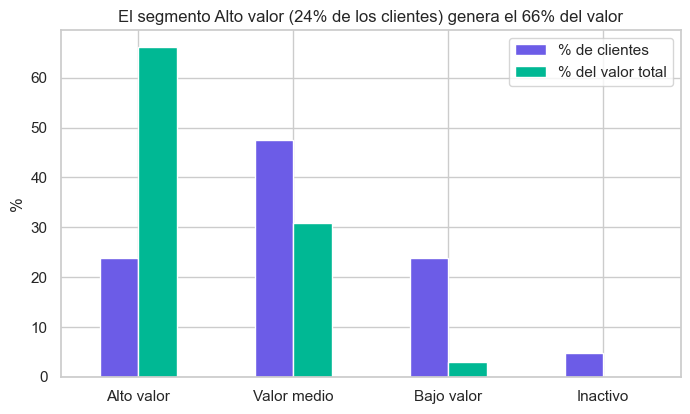

In [62]:
# ¿Cuánto del valor total concentra cada segmento?
valor_por_segmento = df_int.groupby('segmento')['indice_valor'].sum()

concentracion = pd.DataFrame({
    '% de clientes': (df_int['segmento'].value_counts(normalize=True) * 100).round(1),
    '% del valor total': (valor_por_segmento / valor_por_segmento.sum() * 100).round(1),
}).reindex(ORDEN_SEG)
display(concentracion)

concentracion.plot(kind='bar', figsize=(8, 4.5), color=['#6c5ce7', '#00b894'])
plt.title('El segmento Alto valor (24% de los clientes) genera el 66% del valor')
plt.ylabel('%')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

**Interpretación de P7:**
- **Tamaños:** Alto valor 1.281 clientes (23,8%), Valor medio 2.561 (47,6%), Bajo valor 1.281 (23,8%) e Inactivo 261 (4,8%). Alto valor genera el 66% del valor total y Bajo valor solo el 3,0%.
- **El valor lo define el estrato.** Alto valor es Muy Alto (56%) y Alto (44%), con ingreso medio de $10.288 y 86% de membresía premium. Bajo valor es sobre todo estrato Bajo (69%) y Medio (27%), con ingreso medio de $1.787. Los 261 inactivos son todos de estrato Bajo (ingreso mediano de $1.184).
- **La preferencia es independiente del valor** (P2): en todos los segmentos entre 31% y 33% es vegetariano/vegano. Una campaña de contenido y una de inversión se piensan por separado.
- **Oportunidad:** 424 clientes de Alto valor prefieren cocina vegetariana/vegana, y Yelp tiene solo 2 restaurantes para ellos.

### P8 · ¿Dónde está el potencial de crecimiento?

El índice mezcla cuánto gasta el cliente por visita y cuántas veces visita. Separando las dos (cortando cada una en la mediana) quedan cuatro tipos de cliente activo. Es una segunda mirada, solo sobre los clientes que visitan: no reemplaza a los segmentos de P7, sino que muestra quiénes podrían visitar más.

| | Visita poco | Visita mucho |
|---|---|---|
| **Gasta mucho** | *Ocasionales de alto gasto* | *Embajadores* |
| **Gasta poco** | *Distantes* | *Frecuentes de bajo gasto* |

La pregunta: ¿cuánto crecería el negocio si los ocasionales de alto gasto visitaran tanto como los embajadores?

In [63]:
# `activos` (los clientes que visitan) ya lo definimos en P7
mediana_frecuencia = activos['frecuencia_visita'].median()
mediana_gasto = activos['promedio_gasto_comida'].median()
print(f'Medianas entre clientes activos: frecuencia = {mediana_frecuencia:.0f} | gasto = ${mediana_gasto:.2f}')

visita_mucho = activos['frecuencia_visita'] > mediana_frecuencia
gasta_mucho = activos['promedio_gasto_comida'] > mediana_gasto

embajadores = activos[visita_mucho & gasta_mucho]
ocasionales = activos[~visita_mucho & gasta_mucho]
frecuentes_economicos = activos[visita_mucho & ~gasta_mucho]
distantes = activos[~visita_mucho & ~gasta_mucho]

Medianas entre clientes activos: frecuencia = 4 | gasto = $20.30


,tipo de cliente,clientes,frecuencia_media,gasto_medio,% del valor total
0,Embajadores,1708,6.3,48.4,73.3
1,Ocasionales de alto gasto,853,3.5,31.4,12.9
2,Frecuentes de bajo gasto,696,5.7,12.7,6.7
3,Distantes,1866,2.6,10.2,7.1


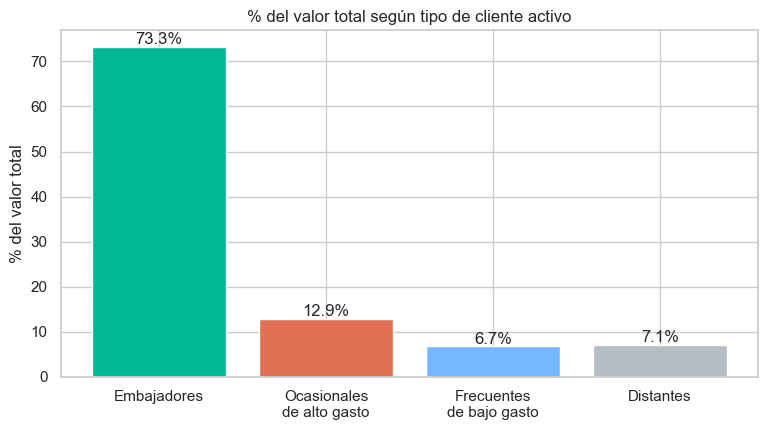

In [64]:
tipos = {'Embajadores': embajadores, 'Ocasionales de alto gasto': ocasionales,
         'Frecuentes de bajo gasto': frecuentes_economicos, 'Distantes': distantes}

filas = []
for nombre, datos in tipos.items():
    filas.append({'tipo de cliente': nombre,
                  'clientes': len(datos),
                  'frecuencia_media': datos['frecuencia_visita'].mean(),
                  'gasto_medio': datos['promedio_gasto_comida'].mean(),
                  '% del valor total': datos['indice_valor'].sum() / df_int['indice_valor'].sum() * 100})
tabla_tipos = pd.DataFrame(filas).round(1)
display(tabla_tipos)

etiquetas = tabla_tipos['tipo de cliente'].str.replace(' de ', '\nde ')   # nombres en dos líneas para que no se pisen

plt.figure(figsize=(9, 4.5))
barras = plt.bar(etiquetas, tabla_tipos['% del valor total'],
                 color=['#00b894', '#e17055', '#74b9ff', '#b2bec3'])
plt.bar_label(barras, fmt='%.1f%%')
plt.title('% del valor total según tipo de cliente activo')
plt.ylabel('% del valor total')
plt.show()

In [65]:
# ¿Qué estrato tienen los ocasionales de alto gasto?
(ocasionales['estrato_socioeconomico'].value_counts(normalize=True) * 100).round(1)

estrato_socioeconomico
Medio    59.4
Alto     40.6
Name: proportion, dtype: float64

In [66]:
# Escenario: ¿cuánto sumaría si los ocasionales de alto gasto visitaran más?
valor_total = df_int['indice_valor'].sum()

extra_una_visita = ocasionales['promedio_gasto_comida'].sum()   # cada uno visita 1 vez más
frecuencia_embajadores = embajadores['frecuencia_visita'].mean()
extra_como_embajadores = ((frecuencia_embajadores - ocasionales['frecuencia_visita']) * ocasionales['promedio_gasto_comida']).sum()

print(f'Una visita más por cliente ocasional:            +{extra_una_visita / valor_total:.1%} del valor total')
print(f'Visitando como los embajadores ({frecuencia_embajadores:.1f} visitas):    +{extra_como_embajadores / valor_total:.1%} del valor total')

Una visita más por cliente ocasional:            +3.6% del valor total
Visitando como los embajadores (6.3 visitas):    +9.8% del valor total


**Interpretación de P8:**
- **Embajadores:** 1.708 clientes, 6,3 visitas y $48,4 por visita. Concentran el 73% del valor.
- **Ocasionales de alto gasto:** 853 clientes que gastan $31,4 por visita pero visitan solo 3,5 veces. Son de estrato Medio (59%) y Alto (41%). Tienen el presupuesto; les falta frecuencia.
- **Frecuentes de bajo gasto:** 696 clientes con 5,7 visitas y $12,7 por visita. Pesan solo el 6,7% del valor; su mejora está en el ticket (combos, upselling).
- **Escenario:** si cada ocasional visitara una vez más, el valor total subiría 3,6%; si visitara con la frecuencia de los embajadores (6,3 visitas), subiría 9,8%, más que todo lo que hoy aportan los frecuentes de bajo gasto (6,7%).
- Es un escenario, no una predicción: supone que el gasto por visita se mantiene y habría que probarlo.

### La base final
Es la **base unificada del Avance #2** más lo que agregamos en este análisis: grupo de edad, índice de valor y segmento. Queda en memoria; los CSV de `data/` no cambian.

In [67]:
print(f'Base final: {df_int.shape[0]:,} clientes x {df_int.shape[1]} columnas')
df_int[['id_persona', 'grupo_preferencia', 'n_restaurantes', 'grupo_edad', 'indice_valor', 'segmento']].head()

Base final: 5,384 clientes x 21 columnas


,id_persona,grupo_preferencia,n_restaurantes,grupo_edad,indice_valor,segmento
0,3456521319,Vegetariano/Vegano,2.0,51-70,46.04,Valor medio
1,2916502228,Mariscos y pescado,21.0,31-50,15.21,Bajo valor
2,5736368501,Carnes,32.0,51-70,171.75,Valor medio
3,9718391309,Vegetariano/Vegano,2.0,51-70,6.59,Bajo valor
4,9148064715,Mariscos y pescado,21.0,71+,624.16,Alto valor


## 9. Recomendaciones de segmentación

Resumen de lo que dicen los datos de los clientes de Chicago y qué hacer con eso. El documento completo, pensado para el equipo comercial, está en `Documentacion/Recomendaciones.pdf`.

### Hallazgos clave
1. **El valor lo define el estrato, y la preferencia alimenticia no tiene relación con él.** Preferencia y estrato son independientes (V de Cramér = 0,03), así que cada segmento de valor tiene la misma mezcla de preferencias.
2. **El 24% de los clientes genera el 66% del valor.** Son de estratos Alto y Muy Alto, con ingresos medios de $10.288.
3. **La membresía premium no aumenta el gasto por sí sola:** refleja el estrato. Dentro de un mismo estrato, premium y no premium gastan igual.
4. **Vegetarianos y veganos son el mayor grupo (31,5%) y casi no tienen oferta** en Yelp (2 restaurantes, 847 clientes por restaurante).
5. **Hay una brecha de precio:** el 28% de los clientes que visitan gasta hasta $10 por visita, pero solo el 0,7% de los restaurantes con precio es `$`.
6. **El licor depende de la edad, no del estrato:** lo consume el 90% de los clientes de 18 a 30 años y el 55% de los demás.
7. **Los ocasionales de alto gasto son la palanca de crecimiento:** 853 clientes con presupuesto que visitan poco; que lleguen a la frecuencia de los embajadores sumaría ~10% al valor.
8. **Hay "joyas ocultas" en Yelp:** 24 restaurantes muy bien calificados y poco conocidos, porque el rating baja a medida que suben las reseñas.
9. **Género, medio de pago y ocio no diferencian el comportamiento** (y la edad solo importa para el licor).
10. **1 de cada 4 clientes no tiene correo ni teléfono** (1.359), así que no se lo puede contactar directamente.

### Recomendaciones

| Prioridad | Segmento / tema | Acción propuesta | Evidencia | Cómo medirlo |
|---|---|---|---|---|
| 1 | **Alto valor** (1.281 clientes) | Programa de retención y experiencias exclusivas; comunicaciones personalizadas según su preferencia alimenticia. Es el segmento a proteger. | 24% de los clientes, 66% del valor total, 86% premium. | Retención y frecuencia de visita del segmento. |
| 2 | **Ocasionales de alto gasto** (853 clientes) | Beneficios por visita adicional (segundo canje, recordatorios, eventos) para acercar su frecuencia a la de los embajadores. | Gastan $31 por visita pero visitan 3,5 veces (embajadores: 6,3). Una visita más suma 3,6% al valor total; igualar a los embajadores, 9,8%. | Visitas por cliente, grupo de prueba vs. control. |
| 3 | **Vegetarianos/veganos de Alto valor** (424 clientes) | Campañas de descubrimiento con los pocos restaurantes vegetarianos que existen y captación de nuevos negocios aliados con esa oferta. | 31,5% de la demanda frente a 0,8% de la oferta; el rating de esa oferta (4,10) es el más bajo. | Reservas y cupones canjeados en aliados vegetarianos; nuevos aliados sumados. |
| 4 | **Jóvenes de 21 a 30 años** (887 clientes) | Alianzas con bares y coctelería, dirigidas por edad y no por estrato, solo a mayores de 21 (la edad legal para tomar alcohol en EE. UU.). | El 90,5% de este grupo consume licor (contra ~55% de los mayores de 30); el 43% de los restaurantes de Yelp tiene categoría de bar. | Canjes en bares por grupo de edad. |
| 5 | **Bajo valor** (1.281) e **Inactivos** (261) | Ofertas accesibles por delivery y combos en restaurantes `$$`, y sumar restaurantes económicos como aliados. Reactivación simple con incentivo de primera visita. | El 28% de los clientes gasta hasta $10 y solo el 0,7% de los restaurantes es `$`. Los inactivos son todos de estrato Bajo. | Costo por visita incremental; tasa de reactivación. |
| 6 | **Joyas ocultas de Yelp** (24 restaurantes) | Promocionarlas en las campañas de descubrimiento, previo relevamiento de sus precios (19 no lo informan). | Rating de 4,6 o más, 30 o más reseñas y por debajo de la mediana de visibilidad. | Reservas y clics por restaurante promocionado. |
| 7 | **Membresía premium** | No asumir que sube el gasto: probarlo con un test A/B en el segmento Valor medio (2.561). | Dentro de cada estrato, premium y no premium gastan lo mismo. | Aumento de gasto por cliente, grupo de prueba vs. control. |
| 8 | **Medios de pago** | Que las promociones se puedan canjear en el local y no solo con app. No priorizar criptomonedas. | El efectivo es el 39% de los pagos y la cripto solo 1,8%. | Canjes por medio de pago. |
| 9 | **Calidad del dato** | Completar los datos de contacto, capturar la preferencia alimenticia en el alta (5% sin dato: el estrato no permite deducirla), validar edad y frecuencia en el origen y controlar correos repetidos. | 1.359 clientes sin correo ni teléfono, 29 edades inválidas, 286 frecuencias negativas y 14 correos repetidos. | % de clientes contactables y % de registros con errores. |

> **Cómo llegar a los clientes:** 1 de cada 4 clientes no tiene correo ni teléfono. Para ellos, las acciones tienen que apoyarse en los restaurantes aliados (promociones que se ven y se canjean en el local), mientras se completan sus datos (recomendación 9).

> **Nota:** las recomendaciones 3 y 4 combinan un segmento con una preferencia o una edad, aprovechando que las variables son independientes entre sí. El mismo criterio puede aplicarse a los demás segmentos.

Debajo de esta tabla hay **un gráfico por recomendación** con el dato que la respalda.

### Un gráfico por recomendación
Cada gráfico muestra el dato que justifica la recomendación. Usamos variables que ya calculamos en las preguntas P1 a P8.

**Recomendación 1 · Alto valor (1.281 clientes): retener al segmento que más vale.**
Comparamos el valor promedio de un cliente (gasto por visita × frecuencia) en cada segmento.

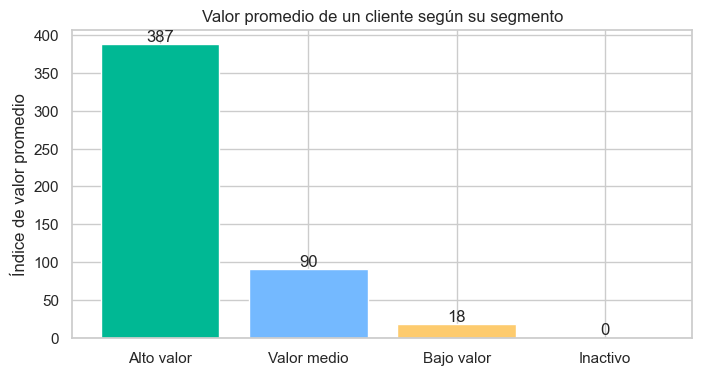

Un cliente de Alto valor vale 4.3 veces uno de Valor medio


In [68]:
valor_promedio = df_int.groupby('segmento')['indice_valor'].mean().reindex(ORDEN_SEG)

plt.figure(figsize=(8, 4))
barras = plt.bar(valor_promedio.index, valor_promedio.values, color=['#00b894', '#74b9ff', '#fdcb6e', '#b2bec3'])
plt.bar_label(barras, fmt='%.0f')
plt.title('Valor promedio de un cliente según su segmento')
plt.ylabel('Índice de valor promedio')
plt.show()

print(f"Un cliente de Alto valor vale {valor_promedio['Alto valor'] / valor_promedio['Valor medio']:.1f} veces uno de Valor medio")

**Recomendación 2 · Ocasionales de alto gasto (853 clientes): que visiten más.**
Tienen presupuesto, pero visitan bastante menos que los embajadores.

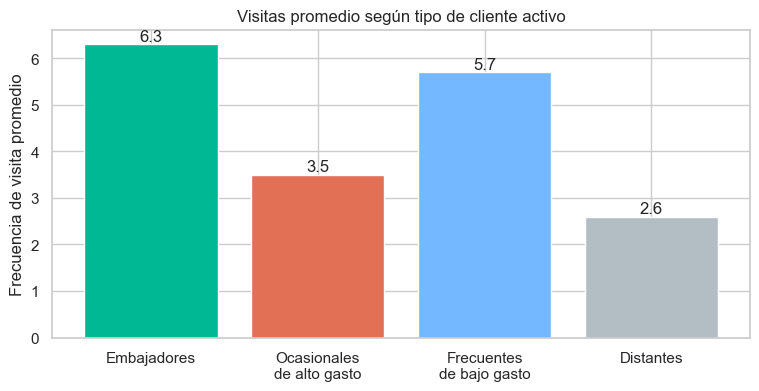

In [69]:
plt.figure(figsize=(9, 4))
barras = plt.bar(etiquetas, tabla_tipos['frecuencia_media'], color=['#00b894', '#e17055', '#74b9ff', '#b2bec3'])
plt.bar_label(barras, fmt='%.1f')
plt.title('Visitas promedio según tipo de cliente activo')
plt.ylabel('Frecuencia de visita promedio')
plt.show()

**Recomendación 3 · Vegetarianos y veganos de Alto valor (424 clientes): sumar oferta vegetariana.**
Es el grupo más grande dentro de Alto valor, pero casi no hay restaurantes para ellos.

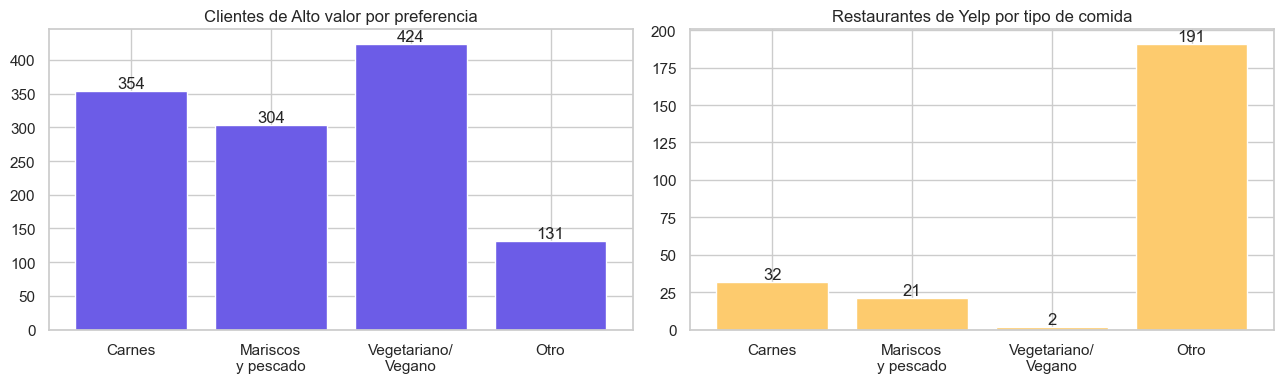

In [70]:
alto_valor = df_int[df_int['segmento'] == 'Alto valor']
alto_por_grupo = alto_valor['grupo_preferencia'].value_counts().reindex(nombres_grupos)
restaurantes_por_grupo = oferta.set_index('grupo_preferencia')['n_restaurantes'].reindex(nombres_grupos)
etiquetas_grupos = [g.replace(' y ', '\ny ').replace('/', '/\n') for g in nombres_grupos]   # nombres en dos líneas

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
barras = ejes[0].bar(etiquetas_grupos, alto_por_grupo.values, color='#6c5ce7')
ejes[0].bar_label(barras)
ejes[0].set_title('Clientes de Alto valor por preferencia')
barras = ejes[1].bar(etiquetas_grupos, restaurantes_por_grupo.values, color='#fdcb6e')
ejes[1].bar_label(barras)
ejes[1].set_title('Restaurantes de Yelp por tipo de comida')
plt.tight_layout()
plt.show()

**Recomendación 4 · Jóvenes de 21 a 30 años (887 clientes): campañas de licor por edad, no por estrato.**
El consumo de licor cambia mucho con la edad y casi nada con el estrato. El gráfico muestra el grupo de 18 a 30 años, pero la campaña se dirige solo a mayores de 21, la edad legal para tomar alcohol en EE. UU.

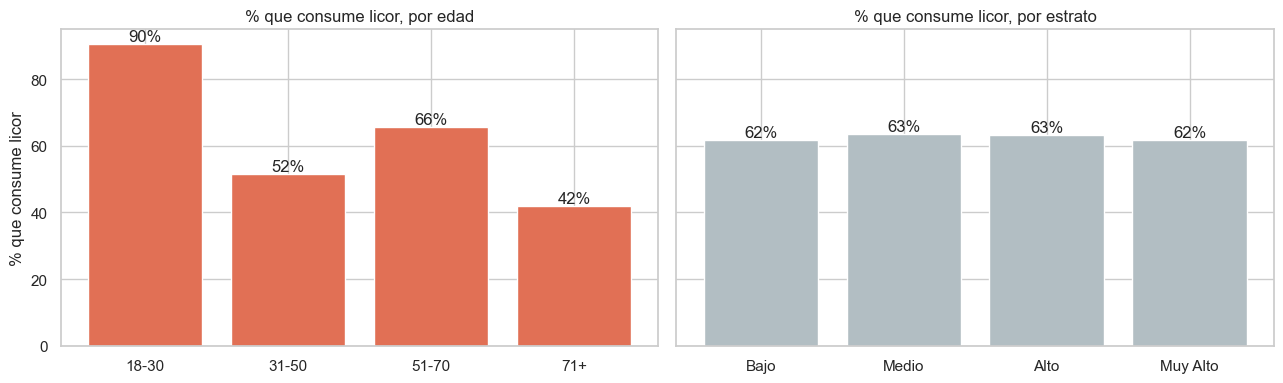

In [71]:
licor_por_grupo_edad = (df_int['consume_licor'] == 'Sí').groupby(df_int['grupo_edad'], observed=True).mean() * 100
licor_por_estrato = (df_int['consume_licor'] == 'Sí').groupby(df_int['estrato_socioeconomico']).mean().reindex(ORDEN_ESTRATO) * 100

fig, ejes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
barras = ejes[0].bar(licor_por_grupo_edad.index.astype(str), licor_por_grupo_edad.values, color='#e17055')
ejes[0].bar_label(barras, fmt='%.0f%%')
ejes[0].set_title('% que consume licor, por edad')
ejes[0].set_ylabel('% que consume licor')
barras = ejes[1].bar(licor_por_estrato.index, licor_por_estrato.values, color='#b2bec3')
ejes[1].bar_label(barras, fmt='%.0f%%')
ejes[1].set_title('% que consume licor, por estrato')
plt.tight_layout()
plt.show()

**Recomendación 5 · Bajo valor (1.281) e Inactivos (261): ofertas accesibles.**
Comparamos cuánto gastan por visita los clientes de Bajo valor con los precios de los restaurantes de Yelp. (Los Inactivos no visitan, así que no tienen gasto; son todos de estrato Bajo.)

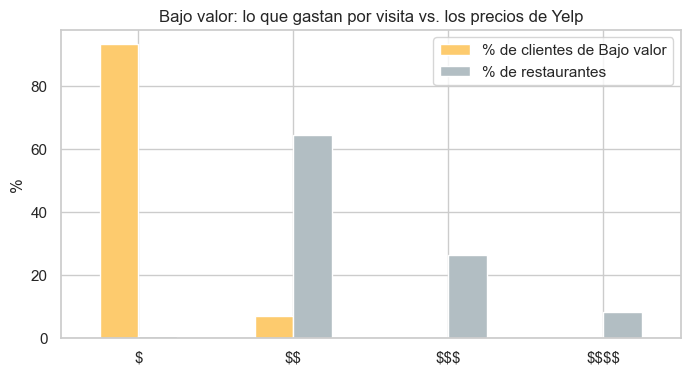

In [72]:
bajo_valor = df_int[df_int['segmento'] == 'Bajo valor']
rango_bajo = pd.cut(bajo_valor['promedio_gasto_comida'], bins=RANGOS_PRECIO, labels=ETIQUETAS_PRECIO)

comparacion_bajo = pd.DataFrame({
    '% de clientes de Bajo valor': rango_bajo.value_counts(normalize=True) * 100,
    '% de restaurantes': pct_restaurantes,
}).reindex(ETIQUETAS_PRECIO).fillna(0)

comparacion_bajo.plot(kind='bar', figsize=(8, 4), color=['#fdcb6e', '#b2bec3'])
plt.title('Bajo valor: lo que gastan por visita vs. los precios de Yelp')
plt.ylabel('%')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

**Recomendación 6 · Joyas ocultas de Yelp (24 restaurantes): promocionarlas.**
Están arriba (muy bien calificadas) y a la izquierda (pocas reseñas): buenas y poco conocidas.

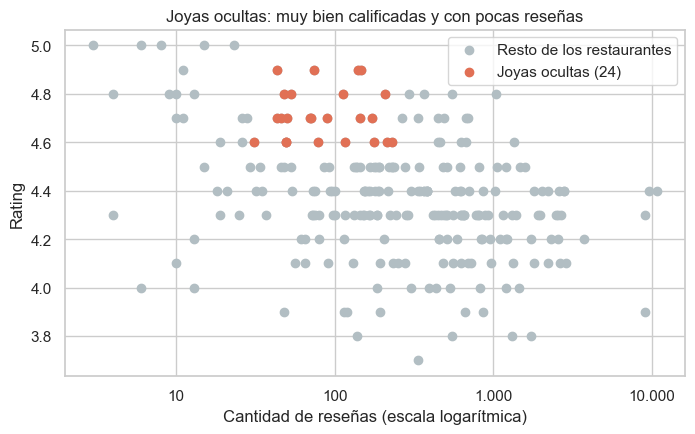

In [73]:
plt.figure(figsize=(8, 4.5))
plt.scatter(df_yelp['review_count'], df_yelp['rating'], color='#b2bec3', label='Resto de los restaurantes')
plt.scatter(joyas['review_count'], joyas['rating'], color='#e17055', label='Joyas ocultas (24)')
plt.xscale('log')   # escala logarítmica: las reseñas van de unas pocas a más de 10.000
plt.xticks([10, 100, 1000, 10000], ['10', '100', '1.000', '10.000'])
plt.xlabel('Cantidad de reseñas (escala logarítmica)')
plt.ylabel('Rating')
plt.title('Joyas ocultas: muy bien calificadas y con pocas reseñas')
plt.legend()
plt.show()

**Recomendación 7 · Membresía premium: probarla antes de invertir.**
Dentro de un mismo estrato, premium y no premium gastan casi lo mismo. (No incluimos el estrato Bajo porque tiene solo 8 clientes premium.)

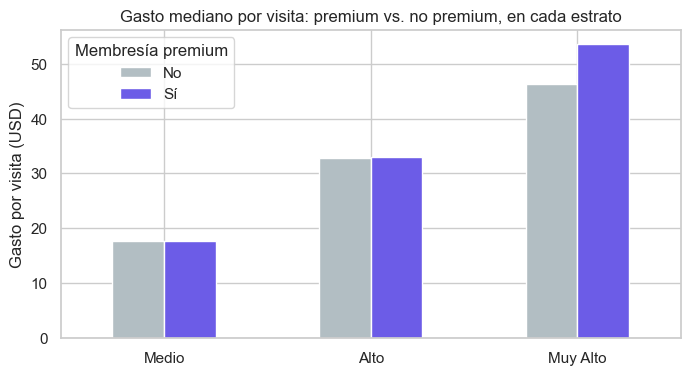

In [74]:
gasto_premium = df_int.groupby(['estrato_socioeconomico', 'membresia_premium'])['promedio_gasto_comida'].median().unstack().reindex(['Medio', 'Alto', 'Muy Alto'])

gasto_premium.plot(kind='bar', figsize=(8, 4), color=['#b2bec3', '#6c5ce7'])
plt.title('Gasto mediano por visita: premium vs. no premium, en cada estrato')
plt.ylabel('Gasto por visita (USD)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Membresía premium')
plt.show()

**Recomendación 8 · Medios de pago: que las promociones se puedan canjear en el local.**
El efectivo es el medio más usado; la criptomoneda casi no se usa.

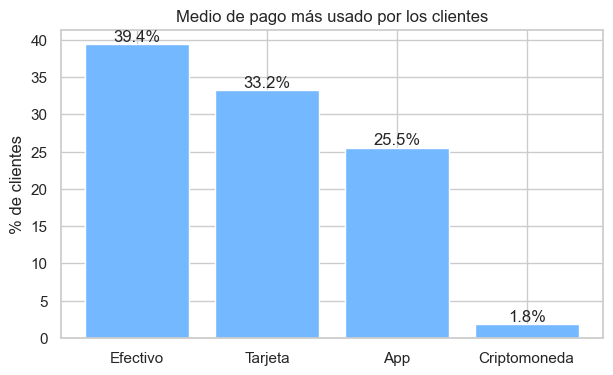

In [75]:
pagos = df_int['tipo_de_pago_mas_usado'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 4))
barras = plt.bar(pagos.index, pagos.values, color='#74b9ff')
plt.bar_label(barras, fmt='%.1f%%')
plt.title('Medio de pago más usado por los clientes')
plt.ylabel('% de clientes')
plt.show()

**Recomendación 9 · Calidad de datos: completar el contacto y validar en el origen.**
Los problemas que encontramos en la limpieza (Avance 1), contados sobre la base de Chicago antes de limpiar.

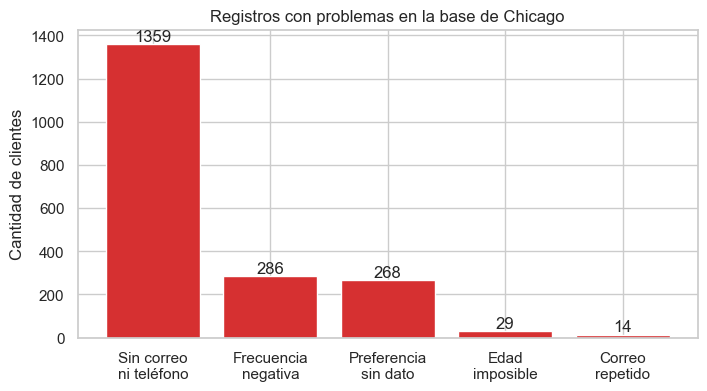

In [76]:
problemas = pd.Series({
    'Sin correo\nni teléfono': (df_ciudad['correo_electronico'].isnull() & df_ciudad['telefono_contacto'].isnull()).sum(),
    'Frecuencia\nnegativa': (df_ciudad['frecuencia_visita'] < 0).sum(),
    'Preferencia\nsin dato': df_ciudad['preferencias_alimenticias'].isnull().sum(),
    'Edad\nimposible': ((df_ciudad['edad'] < 18) | (df_ciudad['edad'] > 100)).sum(),
    'Correo\nrepetido': df_ciudad['correo_electronico'].dropna().duplicated().sum(),
})

plt.figure(figsize=(8, 4))
barras = plt.bar(problemas.index, problemas.values, color='#d63031')
plt.bar_label(barras)
plt.title('Registros con problemas en la base de Chicago')
plt.ylabel('Cantidad de clientes')
plt.show()

## 10. Limitaciones a tener en cuenta
- **Yelp es una muestra:** los 240 restaurantes son el 3% de los 7.900 que Yelp registra, ordenados por relevancia. Favorecen a los negocios populares (mediana de 234 reseñas) y probablemente subrepresentan a los baratos: solo 1 figura con precio `$` y el 40% no informa precio.
- **Los rangos de precio de Yelp son aproximados** (`$` hasta 10 USD, `$$` de 11 a 30, `$$$` de 31 a 60, `$$$$` más de 60), así que la brecha de precio es una estimación.
- **El cruce por tipo de comida es una aproximación:** las categorías de Yelp describen el tipo de negocio, no el menú. El análisis de sensibilidad (definición amplia: 9 restaurantes, 3,8%) no cambia la conclusión.
- **1 de cada 4 clientes no tiene correo ni teléfono** (1.359), así que las acciones directas no les llegan.
- **Ciudad de residencia no es ciudad de consumo:** asumimos que los clientes comen en Chicago.
- **El índice de valor es relativo:** no conocemos la unidad de `frecuencia_visita`. El escenario de crecimiento (+3,6% y +9,8%) es una simulación, no una predicción.
- **Los datos de clientes son sintéticos** (provistos por el curso): relaciones tan limpias, como el salto del licor entre los 30 y los 31 años, pueden no darse en datos reales.
- **Correlación no es causalidad,** como mostró la membresía premium.
- **Se probaron muchas relaciones a la vez** (28 pares en el mapa de asociaciones), por lo que alguna podría salir por azar; las dos que destacamos están muy lejos del ruido.